## Educational Project

This project is an educational reproduction of a case study developed by USP (University of São Paulo) students. It is intended exclusively for learning, self-study, and portfolio demonstration. All credit for the original study design and analysis belongs to the original USP research team.

The project presented here is an educational and portfolio-oriented reproduction of the original study, created for technical learning and demonstration purposes.

Source: ICMC — https://www.icmc.usp.br/noticias/6869-trabalho-da-usp-analisa-aspectos-que-impactam-a-felicidade-ao-redor-do-mundo

## Objective: Analysis of Happiness Around the World

[Kaggle Dataset](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated?select=World-happiness-report-updated_2024.csv)

## Dataset Attribute Description

* Country name: Name of the country.
* Regional indicator: Region to which the country belongs.
* Ladder score: The happiness score for each country, based on responses to the Cantril Ladder question that asks respondents to think of a ladder, with the best possible life for them being a 10, and the worst possible life being a 0.
* Log GDP per capita: The natural logarithm of the country's GDP per capita, adjusted for purchasing power parity (PPP) to account for differences in the cost of living between countries.
* Social support: The national average of binary responses (either 0 or 1 representing No/Yes) to the question about having relatives or friends to count on in times of trouble.
* Healthy life expectancy: The average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages.
* Freedom to make life choices: The national average of responses to the question about satisfaction with freedom to choose what to do with one's life.
* Generosity: The residual of regressing the national average of responses to the question about donating money to charity on GDP per capita.
* Perceptions of corruption: The national average of survey responses to questions about the perceived extent of corruption in the government and businesses.
* Positive affect: The national average of responses to questions about positive emotions experienced yesterday.
* Negative affect: The national average of responses to questions about negative emotions experienced yesterday.
* Regional indicator: The region that the country is part of

# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_predict

# Interpretability
import shap

project_root = Path.cwd()
data_dir = project_root / "data-analysis" / "happiness-report-case-study"
if not data_dir.exists():
    data_dir = project_root

c:\Users\Vitor Morais\projects-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LOADING DATA FROM THE FIRST FILE
df1 = pd.read_csv(data_dir / "World-happiness-report-updated_2024.csv", encoding='latin-1')
df1.head(20)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.500,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.800,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.100,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.400,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.700,0.531,0.234,0.776,0.614,0.268
5,Afghanistan,2013,3.572,7.680,0.484,52.000,0.578,0.059,0.823,0.547,0.273
6,Afghanistan,2014,3.131,7.671,0.526,52.300,0.509,0.102,0.871,0.492,0.375
7,Afghanistan,2015,3.983,7.654,0.529,52.600,0.389,0.078,0.881,0.491,0.339
8,Afghanistan,2016,4.220,7.650,0.559,52.925,0.523,0.040,0.793,0.501,0.348
9,Afghanistan,2017,2.662,7.648,0.491,53.250,0.427,-0.123,0.954,0.435,0.371


In [3]:
df2 = pd.read_csv(data_dir / "World-happiness-report-2024.csv", encoding='latin-1')
df2.head(20)

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,Western Europe,7.319,7.383,7.256,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,Western Europe,7.302,7.389,7.215,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,Western Europe,7.122,7.213,7.031,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,Western Europe,7.060,7.147,6.973,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,North America and ANZ,7.057,7.141,6.973,1.854,1.461,0.692,0.756,0.225,0.323,1.745


In [4]:
df_regioes = df2[['Country name', 'Regional indicator']]
df_regioes.head(20)

,Country name,Regional indicator
0,Finland,Western Europe
1,Denmark,Western Europe
2,Iceland,Western Europe
3,Sweden,Western Europe
4,Israel,Middle East and North Africa
5,Netherlands,Western Europe
6,Norway,Western Europe
7,Luxembourg,Western Europe
8,Switzerland,Western Europe
9,Australia,North America and ANZ


In [5]:
# Merge df1 with df_regioes
df = pd.merge(df1, df_regioes, on="Country name", how="left")
df.head(20)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Regional indicator
0,Afghanistan,2008,3.724,7.350,0.451,50.500,0.718,0.164,0.882,0.414,0.258,South Asia
1,Afghanistan,2009,4.402,7.509,0.552,50.800,0.679,0.187,0.850,0.481,0.237,South Asia
2,Afghanistan,2010,4.758,7.614,0.539,51.100,0.600,0.118,0.707,0.517,0.275,South Asia
3,Afghanistan,2011,3.832,7.581,0.521,51.400,0.496,0.160,0.731,0.480,0.267,South Asia
4,Afghanistan,2012,3.783,7.661,0.521,51.700,0.531,0.234,0.776,0.614,0.268,South Asia
5,Afghanistan,2013,3.572,7.680,0.484,52.000,0.578,0.059,0.823,0.547,0.273,South Asia
6,Afghanistan,2014,3.131,7.671,0.526,52.300,0.509,0.102,0.871,0.492,0.375,South Asia
7,Afghanistan,2015,3.983,7.654,0.529,52.600,0.389,0.078,0.881,0.491,0.339,South Asia
8,Afghanistan,2016,4.220,7.650,0.559,52.925,0.523,0.040,0.793,0.501,0.348,South Asia
9,Afghanistan,2017,2.662,7.648,0.491,53.250,0.427,-0.123,0.954,0.435,0.371,South Asia


In [6]:
# Fill missing region values with 'Unknown'
df["Regional indicator"] = df["Regional indicator"].fillna("Unknown")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   str    
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
 11  Regional indicator                2363 non-null   str    
dtypes: float64(9), in

In [8]:
# Calculate how many countries answered the survey each year
year_counts = df['year'].value_counts()

# Create a DataFrame with year and count
year_data = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})

# Print the DataFrame
print(year_data)

    Year  Count
0   2017    147
1   2011    146
2   2014    144
3   2019    143
4   2015    142
5   2012    141
6   2016    141
7   2018    141
8   2022    140
9   2023    138
10  2013    136
11  2010    124
12  2021    122
13  2020    116
14  2009    114
15  2008    110
16  2007    102
17  2006     89
18  2005     27


In [9]:
# Total countries
num_paises = df['Country name'].nunique()
print(f"Total number of countries: {num_paises}")

Total number of countries: 165


## Number of Observations per Year
In total, we have 165 different countries in our dataset. In none of the years do we have observations for all 165 countries, and the years 2005 and 2006 have observations from fewer than 100 countries. Therefore, we will filter out years with fewer than 100 observations because they have too little data. This allows us to focus on the most representative years while maintaining a robust analysis.

In [10]:
# Removing the less representative years 2005 and 2006
df = df[df['year'] > 2006]

# Count by year
year_counts = df['year'].value_counts()

# DataFrame with year and count
year_data = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})


year_data

,Year,Count
0,2017,147
1,2011,146
2,2014,144
3,2019,143
4,2015,142
5,2012,141
6,2016,141
7,2018,141
8,2022,140
9,2023,138


In [11]:
# Total number of countries after filtering observations from years above 2006
num_paises = df['Country name'].nunique()
print(f"Total number of countries: {num_paises}")

Total number of countries: 164


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 2247 entries, 0 to 2362
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2247 non-null   str    
 1   year                              2247 non-null   int64  
 2   Life Ladder                       2247 non-null   float64
 3   Log GDP per capita                2220 non-null   float64
 4   Social support                    2234 non-null   float64
 5   Healthy life expectancy at birth  2186 non-null   float64
 6   Freedom to make life choices      2216 non-null   float64
 7   Generosity                        2200 non-null   float64
 8   Perceptions of corruption         2130 non-null   float64
 9   Positive affect                   2225 non-null   float64
 10  Negative affect                   2233 non-null   float64
 11  Regional indicator                2247 non-null   str    
dtypes: float64(9), int64(1

In [13]:
df.isnull().sum()

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   27
Social support                       13
Healthy life expectancy at birth     61
Freedom to make life choices         31
Generosity                           47
Perceptions of corruption           117
Positive affect                      22
Negative affect                      14
Regional indicator                    0
dtype: int64

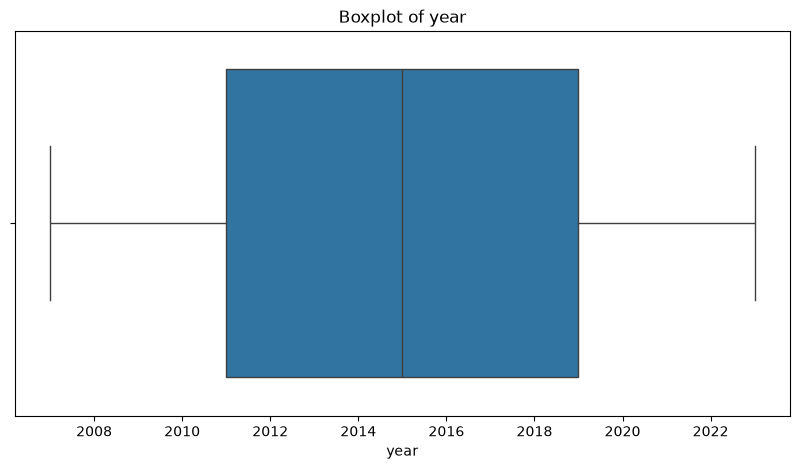

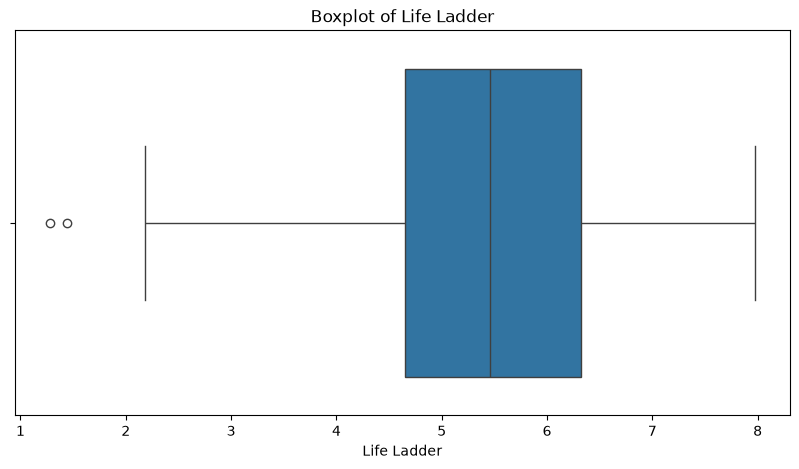

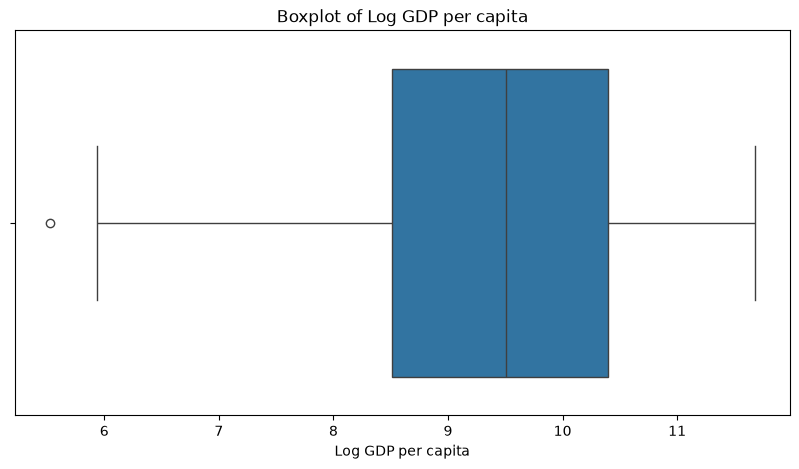

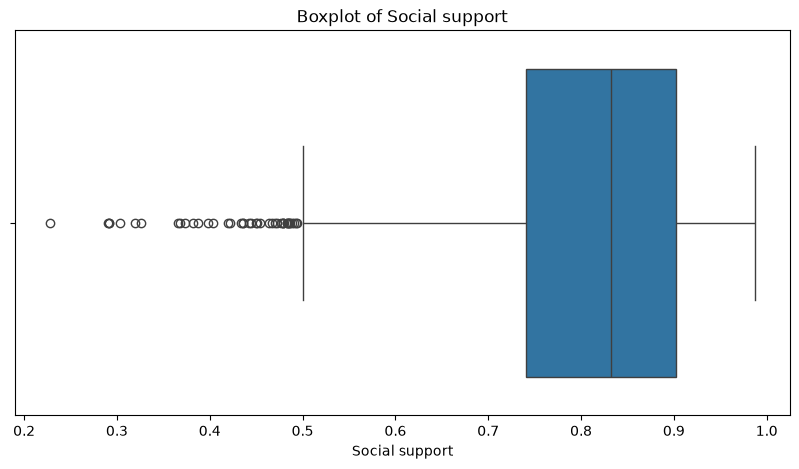

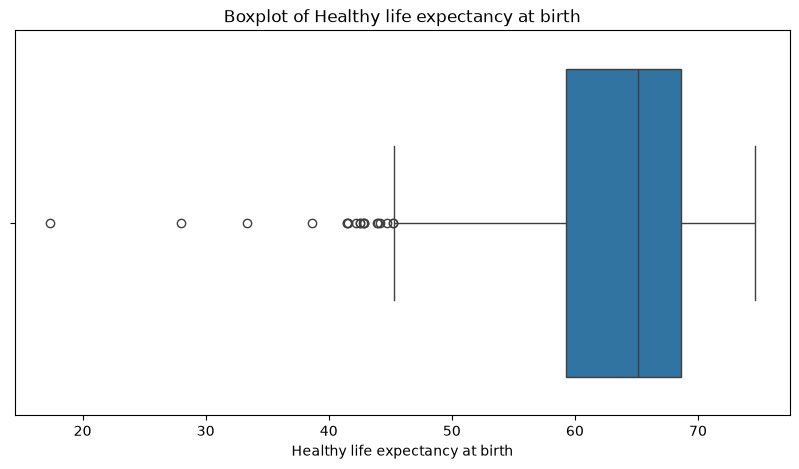

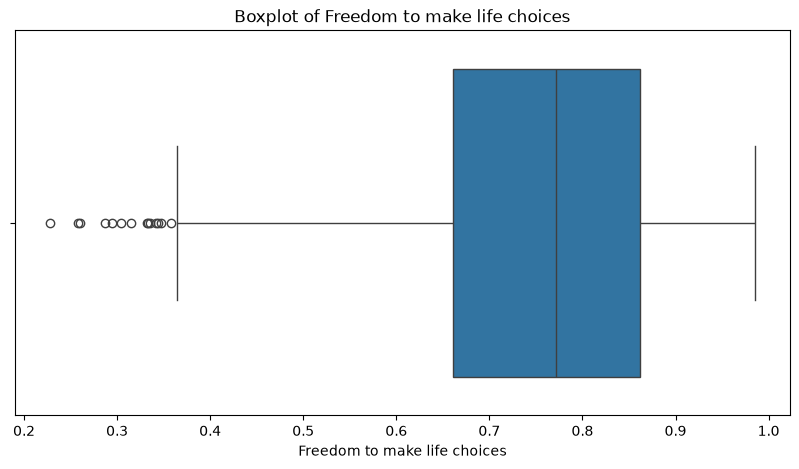

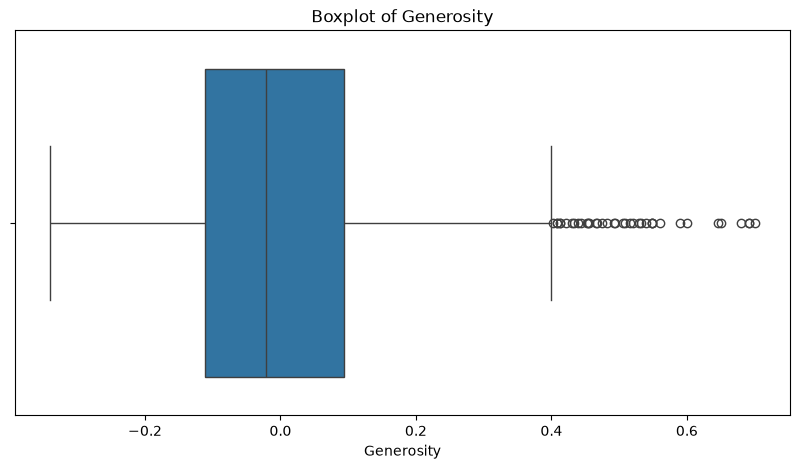

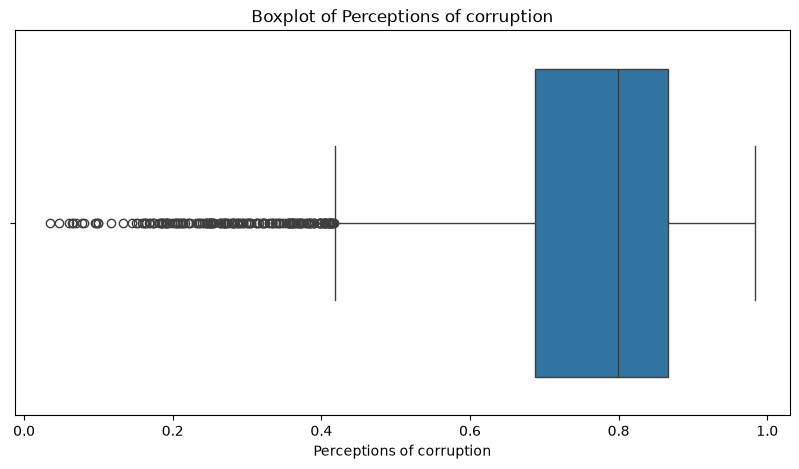

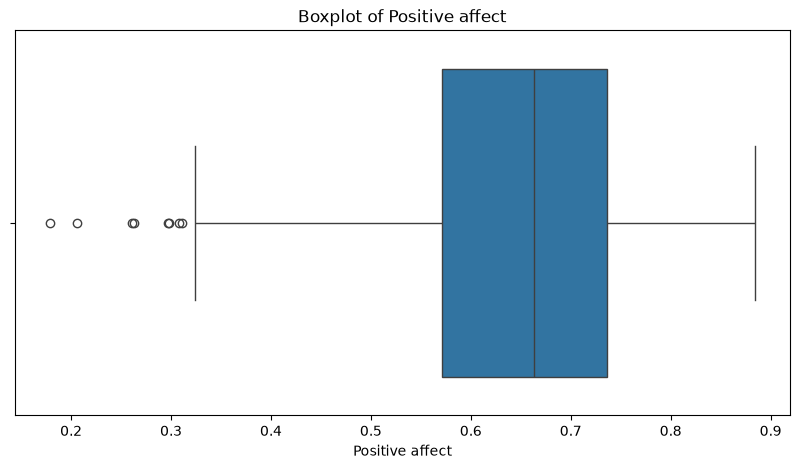

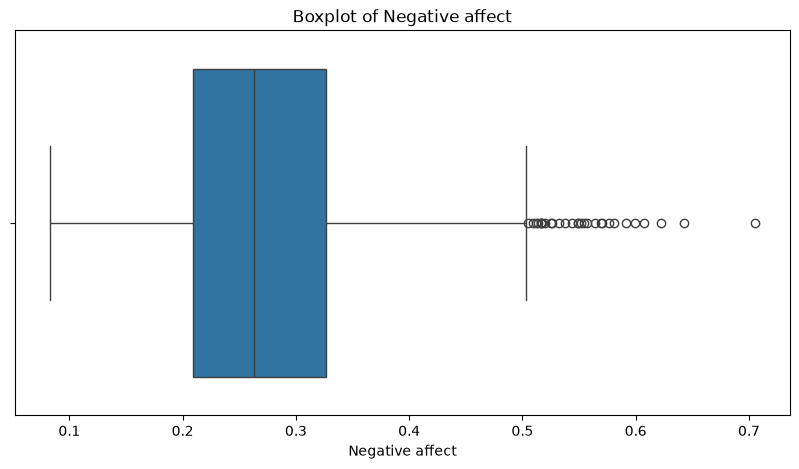

In [14]:
# Analyzing boxplots for numeric columns

numeric_cols = df.select_dtypes(include=np.number)

for column in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column], orient='h')
    plt.title(f'Boxplot of {column}')
    plt.show()

## Boxplot Analysis

Boxplots provide a good overview of the distributions of several variables in our dataset. Below, we analyze each one:

1. Life Ladder

    The boxplot for Life Ladder shows that most happiness scores are concentrated between 4.7 and 6.3, with the median around 5.5. These values suggest a relatively low level of happiness for most cases in the dataset.

2. Log GDP per capita

    For Log GDP per capita, the distribution is concentrated between 8.5 and 10.4, with the median close to 9.5, suggesting that most countries in the dataset have GDP per capita within this range.

3. Social Support

    The boxplot for Social Support shows that most values are between 0.74 and 0.91, with a median of 0.83. However, there is a significant number of outliers below the lower whisker, indicating the presence of extreme values.

4. Healthy life expectancy at birth

    For Healthy life expectancy at birth, most values are between 59 and 68 years, with a median of 65 years. Similarly, we observe outliers below the lower whisker, which indicate unusually low values.

5. Freedom to make life choices

    The Freedom to make life choices variable shows most values between 0.67 and 0.87, with a median around 0.78. As with other variables, there are outliers below the lower whisker.

6. Generosity

    The boxplot for Generosity shows that most values are between -0.13 and +0.09, with a median of -0.02. There are also significant outliers above the upper whisker, suggesting extreme high values.

7. Perceptions of corruption

    The variable Perceptions of corruption has most values between 0.68 and 0.87, with a median around 0.8, although there are outliers below the lower whisker.

8. Positive affect

    In the boxplot for Positive affect, most values are between 0.57 and 0.73, with a median around 0.67. Some outliers below the lower whisker are also observed.

9. Negative affect

    Finally, for Negative affect, most values are between 0.21 and 0.33, with a median of 0.27. However, the presence of outliers above the upper whisker is also notable.

### Presence of Outliers and Decision on Null Value Treatment

A common analysis in boxplots is the presence of outliers, which directly affects how we handle extreme data and null values. We observed that several variables have significant outliers, which can distort measures such as the mean.

Because of this, we decided to use the median for null-value treatment. Unlike the mean, the median is not sensitive to extreme values and provides a more robust representation of the central tendency of the data.

In [15]:
# Replacing null values with the median
imputermediana = SimpleImputer(strategy='median')
df[numeric_cols.columns] = imputermediana.fit_transform(df[numeric_cols.columns])

df.isnull().sum()  # Verify that there are no more null values left

Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
Regional indicator                  0
dtype: int64

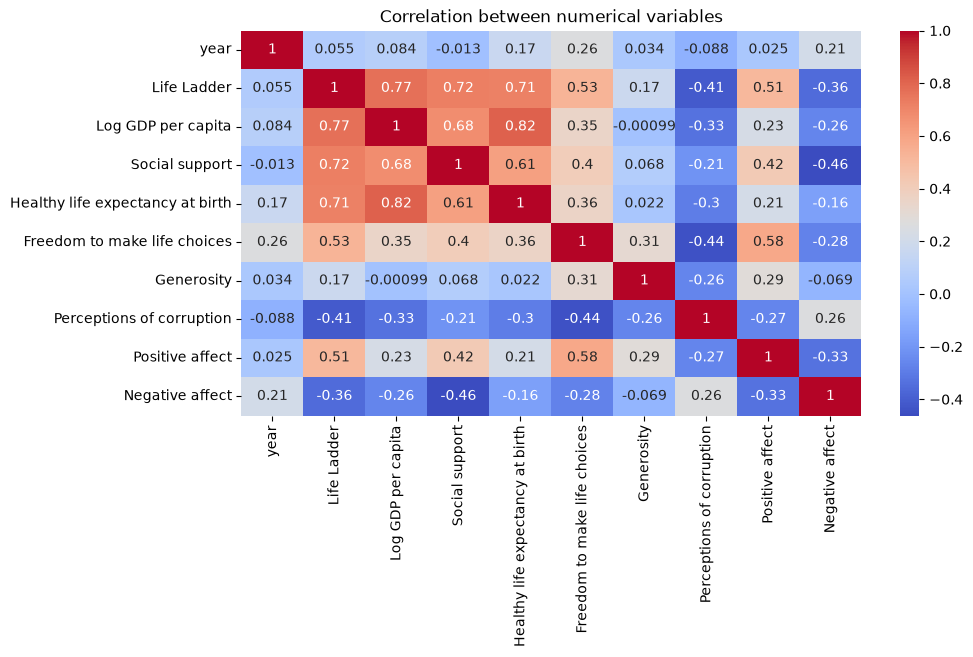

In [16]:
# Analyzing the correlation matrix
correlation_matrix = df[numeric_cols.columns].corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between numerical variables')
plt.show()

## Correlation Matrix Analysis

From the correlation matrix analysis, we can conclude that the 12 most strongly correlated pairs are:

1. Healthy life expectancy at birth and Log GDP per capita = 0.82
2. Life Ladder and Log GDP per capita = 0.77
3. Life Ladder and Social Support = 0.72
4. Healthy life expectancy at birth and Life Ladder = 0.71
5. Log GDP per capita and Social support = 0.68
6. Healthy life expectancy at birth and Social support = 0.61
7. Freedom to make life choices and Positive affect = 0.58
8. Freedom to make life choices and Life Ladder = 0.53
9. Life Ladder and Positive affect = 0.51
10. Negative affect and Social support = -0.46
11. Freedom to make life choices and Perceptions of corruption = -0.44
12. Life Ladder and Perceptions of corruption = -0.41

The first 9 pairs have positive correlation, which indicates that the two variables tend to move in the same direction. The last 3 have negative correlation, which means the variables tend to move in opposite directions.

In addition, from this analysis we can identify several variables with strong direct correlation with the **Life Ladder** attribute (which represents a country's happiness score from 0 to 10):
1. Log GDP per capita (0.77)
2. Social support (0.72)
3. Healthy life expectancy at birth (0.71)
4. Freedom to make life choices (0.53)
5. Positive affect (0.51)
6. Perceptions of corruption (-0.41)

# Analysis of Happiness Today
# QUESTION 1:
# Which countries in the world were happiest and least happy during the pandemic period?

In [17]:
import plotly.express as px   # To create a map
import numpy as np

df_recent_years = df[df['year'].between(2020, 2023)]

# Group by country and region and calculate the mean Life Ladder
df_avg_ladder = df_recent_years.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index()


# Mean and median happiness across countries
media_felicidade_atual = df_avg_ladder['Life Ladder'].mean()
print(f"Average happiness (2020-2023): {media_felicidade_atual}")
mediana_felicidade_atual = df_avg_ladder['Life Ladder'].median()
print(f"Median happiness (2020-2023): {mediana_felicidade_atual}")


# Red, Yellow, Green
custom_color_scale = ['#d62728', '#ffff00', '#2ca02c']

# World map
fig = px.choropleth(df_avg_ladder,
                    locations='Country name',
                    locationmode='country names',
                    color='Life Ladder',
                    color_continuous_scale=custom_color_scale,
                    title='Average Happiness (2020-2023)')
fig.update_layout(
    title={
        'x': 0.5,
        'xanchor': 'center'
    }
)

fig.show()

# Top 10 countries
top_10_countries = df_avg_ladder.nlargest(10, 'Life Ladder')[['Country name', 'Life Ladder']]

# Bottom 10 countries
bottom_10_countries = df_avg_ladder.nsmallest(10, 'Life Ladder')[['Country name', 'Life Ladder']]

# Print results
print("--- CURRENT HAPPINESS ANALYSIS (2020-2023) ---")
print("10 countries with the highest Life Ladder values:")
print(top_10_countries)

print("\n10 countries with the lowest Life Ladder values:")
print(bottom_10_countries)


Average happiness (2020-2023): 5.526596736596736
Median happiness (2020-2023): 5.713


--- CURRENT HAPPINESS ANALYSIS (2020-2023) ---
10 countries with the highest Life Ladder values:
    Country name  Life Ladder
40       Finland      7.77775
32       Denmark      7.56575
53       Iceland      7.53775
94   Netherlands      7.36575
122       Sweden      7.33625
59        Israel      7.30450
100       Norway      7.29900
123  Switzerland      7.17225
77    Luxembourg      7.12200
95   New Zealand      7.08625

10 countries with the lowest Life Ladder values:
         Country name  Life Ladder
0         Afghanistan      1.72100
72            Lebanon      2.68825
73            Lesotho      3.18600
113      Sierra Leone      3.24700
27   Congo (Kinshasa)      3.29500
142          Zimbabwe      3.29575
14           Botswana      3.38350
79             Malawi      3.42100
38           Eswatini      3.50200
140             Yemen      3.56100


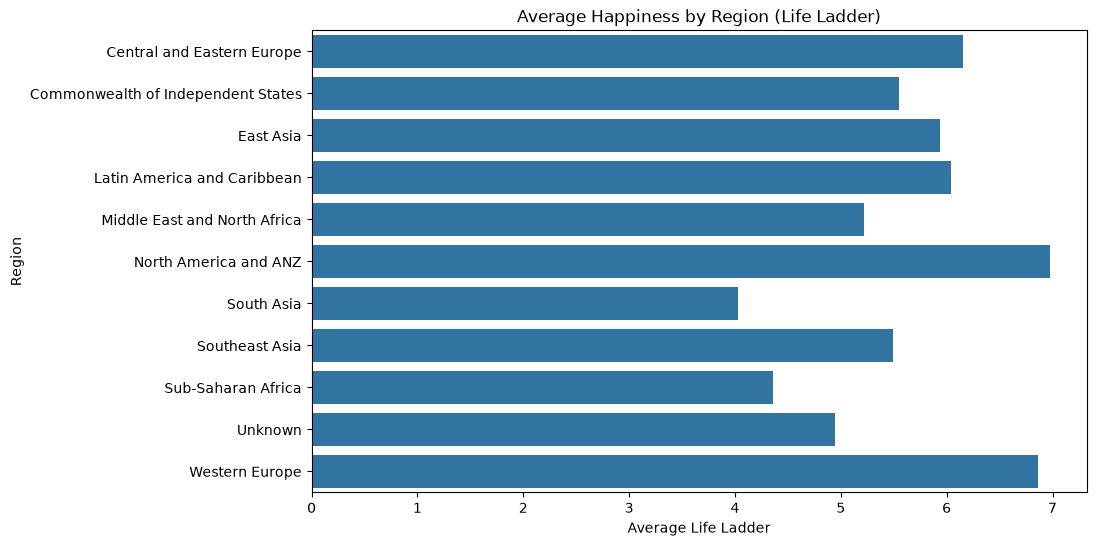

In [18]:
# df with average by region
df_avg_ladder_per_region = df_avg_ladder.groupby('Regional indicator')['Life Ladder'].mean().reset_index()

# Create the chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_avg_ladder_per_region, x='Life Ladder', y='Regional indicator')
plt.xlabel('Average Life Ladder')
plt.ylabel('Region')
plt.title('Average Happiness by Region (Life Ladder)')
plt.show()

The map above represents the average of the "Life Ladder" index recorded between 2020 and 2023, offering a good representation of the happiness level of each country in a recent period.

The United States, Canada, Australia, and New Zealand show a high happiness index, around 7. European countries also have a good happiness index, especially Denmark, Finland, the Netherlands, Iceland, Luxembourg, Norway, Sweden, and Switzerland, all with an average above 7.

Countries in Latin America, Eastern Europe, and Southeast Asia have an intermediate happiness index, with a score close to 6.

It is noticeable that there is a concentration of countries with a low happiness index in Africa and South Asia, with Afghanistan standing out as having the lowest average happiness index in the period analyzed.

# QUESTION 2: Impact of the COVID-19 pandemic on happiness
### Did the pandemic affect countries' happiness?

To analyze the impact of the COVID-19 pandemic on countries' happiness, we will consider 2018 and 2019 as the pre-pandemic period and 2020 and 2021 as the post-pandemic period. Thus, we will calculate the difference in happiness level between these periods using the formula:

LadderScore_PrePandemic = (LadderScore2018 + LadderScore2019) / 2

LadderScore_PostPandemic = (LadderScore2020 + LadderScore2021) / 2

Difference = LadderScore_PostPandemic - LadderScore_PrePandemic

Therefore, if:

* Difference > 0: The country became happier after the pandemic
* Difference < 0: The country became less happy after the pandemic

In [19]:
# Separating data before and after the pandemic
df_pre_pandemia = df[(df['year'] >= 2018) & (df['year'] <= 2019)]
df_pos_pandemia = df[(df['year'] >= 2020) & (df['year'] <= 2021)]

In [20]:
# Calculating the average Ladder Score before the pandemic (2018-2019)
media_pre_pandemia = df_pre_pandemia.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index(name='Average_Pre_Pandemic')

# Calculating the average Ladder Score after the pandemic (2020-2021)
media_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])['Life Ladder'].mean().reset_index(name='Average_Post_Pandemic')

# Merging the averages into a single DataFrame to compare them
df_comparacao = pd.merge(media_pre_pandemia, media_pos_pandemia, on='Country name', how='inner')

In [21]:
df_comparacao.head(5)

,Country name,Regional indicator_x,Average_Pre_Pandemic,Regional indicator_y,Average_Post_Pandemic
0,Afghanistan,South Asia,2.5345,South Asia,2.4360
1,Albania,Central and Eastern Europe,4.9995,Central and Eastern Europe,5.3100
2,Algeria,Middle East and North Africa,4.8940,Middle East and North Africa,5.3275
3,Argentina,Latin America and Caribbean,5.9395,Latin America and Caribbean,5.9045
4,Armenia,Commonwealth of Independent States,5.2750,Commonwealth of Independent States,5.3010


In [22]:
# Calculating the difference between the means
df_comparacao['Ladder_Score_Difference'] = df_comparacao['Average_Post_Pandemic'] - df_comparacao['Average_Pre_Pandemic']

# Renaming the duplicated column to 'Regional indicator'
df_comparacao.rename(columns={'Regional indicator_y': 'Regional indicator'}, inplace=True)

# Removing the redundant 'Regional indicator_x' column
df_comparacao.drop(columns=['Regional indicator_x'], inplace=True)

In [23]:
df_comparacao.head(5)


,Country name,Average_Pre_Pandemic,Regional indicator,Average_Post_Pandemic,Ladder_Score_Difference
0,Afghanistan,2.5345,South Asia,2.4360,-0.0985
1,Albania,4.9995,Central and Eastern Europe,5.3100,0.3105
2,Algeria,4.8940,Middle East and North Africa,5.3275,0.4335
3,Argentina,5.9395,Latin America and Caribbean,5.9045,-0.0350
4,Armenia,5.2750,Commonwealth of Independent States,5.3010,0.0260


In [24]:
# Mean and median of the difference in happiness across countries
media_diferenca = df_comparacao['Ladder_Score_Difference'].mean()
print(f"Average difference in Life Ladder by country before and after the pandemic: {media_diferenca}")
mediana_diferenca = df_comparacao['Ladder_Score_Difference'].median()
print(f"Median difference in Life Ladder by country before and after the pandemic: {mediana_diferenca}")

# Calculating the maximum absolute value to make the scale symmetric
max_abs_diff = max(abs(df_comparacao['Ladder_Score_Difference'].min()), abs(df_comparacao['Ladder_Score_Difference'].max()))

# World map
fig = px.choropleth(
    df_comparacao,
    locations='Country name',
    locationmode='country names',
    color='Ladder_Score_Difference',
    color_continuous_scale='RdBu',
    range_color=[-max_abs_diff, max_abs_diff],
    title='Difference in Happiness Before and After COVID-19',
    color_continuous_midpoint=0
)

fig.update_layout(
    title={
        'x': 0.5,
        'xanchor': 'center'
    }
)

fig.show()

# Top 10 countries
top_10_countries = df_comparacao.nlargest(10, 'Ladder_Score_Difference')[['Country name', 'Ladder_Score_Difference']]

# Bottom 10 countries
bottom_10_countries = df_comparacao.nsmallest(10, 'Ladder_Score_Difference')[['Country name', 'Ladder_Score_Difference']]

# Print results
print("10 countries with the highest difference value")
print(top_10_countries)

print("\n10 countries with the lowest difference value")
print(bottom_10_countries)


Average difference in Life Ladder by country before and after the pandemic: -0.038784
Median difference in Life Ladder by country before and after the pandemic: -0.0034999999999998366


10 countries with the highest difference value
    Country name  Ladder_Score_Difference
24       Croatia                   0.8165
20         China                   0.6795
66      Malaysia                   0.6285
115      Ukraine                   0.6085
92       Romania                   0.5265
64     Lithuania                   0.4415
32       Estonia                   0.4405
2        Algeria                   0.4335
60    Kyrgyzstan                   0.4160
14      Bulgaria                   0.4065

10 countries with the lowest difference value
   Country name  Ladder_Score_Difference
63      Lebanon                  -2.1890
10        Benin                  -0.9475
7       Bahrain                  -0.9250
23   Costa Rica                  -0.6965
54      Jamaica                  -0.6895
21     Colombia                  -0.6675
16     Cambodia                  -0.5940
29      Ecuador                  -0.5740
89  Philippines                  -0.5460
56       Jordan                  -

In [25]:
# Filtering countries with 'Unknown' and 'Commonwealth of Independent States' in the regional indicator
unknown_countries = df_avg_ladder[df_avg_ladder['Regional indicator'] == 'Unknown']['Country name']
cois_countries = df_avg_ladder[df_avg_ladder['Regional indicator'] == 'Commonwealth of Independent States']['Country name']

# Printing the country names
print("Countries with Regional indicator = 'Unknown':")
print(unknown_countries)

print("Countries with Regional indicator = 'Commonwealth of Independent States':")
print(cois_countries)

Countries with Regional indicator = 'Unknown':
130    Türkiye
Name: Country name, dtype: str
Countries with Regional indicator = 'Commonwealth of Independent States':
4         Armenia
7      Azerbaijan
44        Georgia
65     Kazakhstan
69     Kyrgyzstan
86        Moldova
109        Russia
125    Tajikistan
132       Ukraine
137    Uzbekistan
Name: Country name, dtype: str


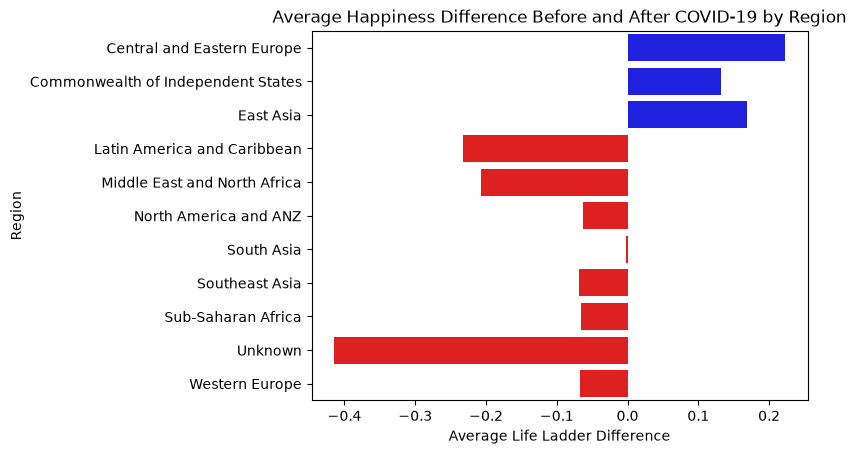

In [26]:
# Analyzing the difference by region
df_comparacao_media_por_regiao = df_comparacao.groupby('Regional indicator')['Ladder_Score_Difference'].mean().reset_index()

# Plotting the chart
bars = sns.barplot(
    data=df_comparacao_media_por_regiao,
    x='Ladder_Score_Difference',
    y='Regional indicator',
    hue='Ladder_Score_Difference',
    dodge=False,
    palette={k: 'red' if k < 0 else 'blue' for k in df_comparacao_media_por_regiao['Ladder_Score_Difference']}
)

# Removing the legend generated by `hue`
bars.legend_.remove()

# Adding labels and title
plt.xlabel('Average Life Ladder Difference')
plt.ylabel('Region')
plt.title('Average Happiness Difference Before and After COVID-19 by Region')
plt.show()

In [27]:
# Calculating the average GDP per capita before the pandemic (2018-2019)
media_PIB_pre_pandemia = df_pre_pandemia.groupby(['Country name', 'Regional indicator'])['Log GDP per capita'].mean().reset_index(name='Average_GDP_Pre_Pandemic')

# Calculating the average GDP per capita after the pandemic (2020-2021)
media_PIB_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])['Log GDP per capita'].mean().reset_index(name='Average_GDP_Post_Pandemic')

# Merging the averages into a single DataFrame for comparison
df_comparacao_PIB = pd.merge(media_PIB_pre_pandemia, media_PIB_pos_pandemia, on='Country name', how='inner')

# Calculating the difference between the averages
df_comparacao_PIB['GDP_Difference'] = df_comparacao_PIB['Average_GDP_Pre_Pandemic'] - df_comparacao_PIB['Average_GDP_Post_Pandemic']

# Renaming the duplicated column to 'Regional indicator'
df_comparacao_PIB.rename(columns={'Regional indicator_y': 'Regional indicator'}, inplace=True)

# Removing the redundant 'Regional indicator_x' column
df_comparacao_PIB.drop(columns=['Regional indicator_x'], inplace=True)

# Joining Ladder Score difference and GDP difference in the same DataFrame
df_analise = pd.merge(
    df_comparacao[['Country name', 'Regional indicator', 'Ladder_Score_Difference']],
    df_comparacao_PIB[['Country name', 'GDP_Difference']],
    on='Country name',
    how='inner'
)

# Calculating the correlation between the variables
correlacao_ladder_pib = df_analise['Ladder_Score_Difference'].corr(df_analise['GDP_Difference'])

# Displaying the correlation
print(f'Correlation between "Life Ladder Difference" and "GDP per capita Difference": {correlacao_ladder_pib}')


Correlation between "Life Ladder Difference" and "GDP per capita Difference": -0.011492129427631568


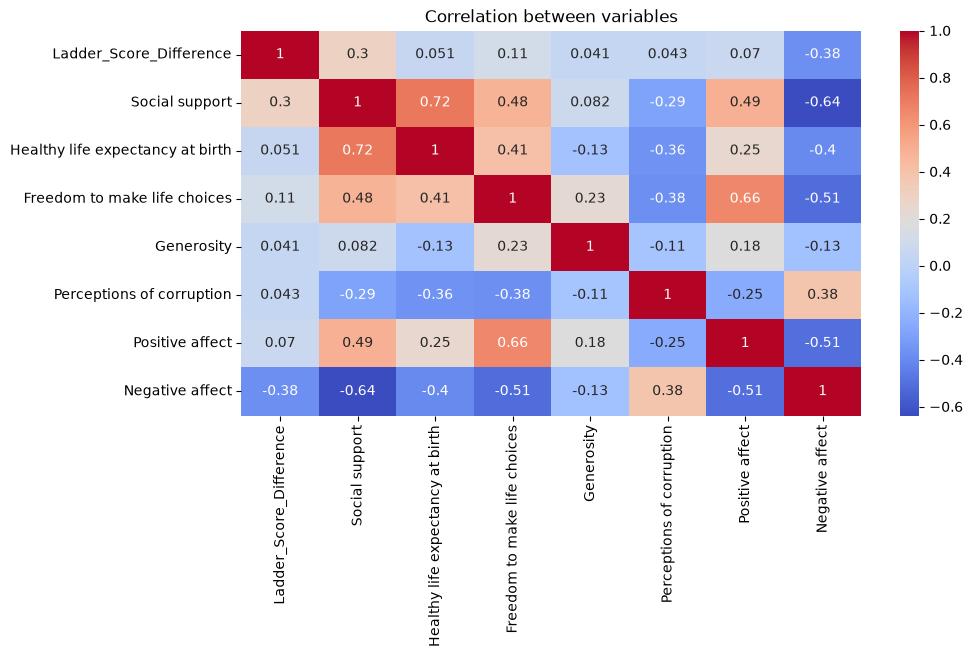

In [28]:
# Variables to aggregate
variables_to_aggregate = ['Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices',
                          'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect']

# Calculating the mean of the variables in the post-pandemic period (2020-2021)
media_variaveis_pos_pandemia = df_pos_pandemia.groupby(['Country name', 'Regional indicator'])[variables_to_aggregate].mean().reset_index()

# Creating a DataFrame with the selected variables + happiness change
df_merge_comparacao = pd.merge(df_comparacao, media_variaveis_pos_pandemia, on=['Country name', 'Regional indicator'], how='inner')

# Dropping unnecessary columns
df_merge_comparacao.drop(columns=['Average_Pre_Pandemic', 'Average_Post_Pandemic'], inplace=True)

# Calculating correlations
numeric_cols = df_merge_comparacao.select_dtypes(include=np.number).columns
correlation_matrix = df_merge_comparacao[numeric_cols].corr()

# Generating the correlation matrix
plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between variables')
plt.show()

In [29]:
df_merge_comparacao

,Country name,Regional indicator,Ladder_Score_Difference,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,South Asia,-0.0985,0.4540,54.5500,0.3940,-0.0850,0.9460,0.1790,0.6070
1,Albania,Central and Eastern Europe,0.3105,0.7060,69.1375,0.7905,0.0205,0.8935,0.5585,0.2595
2,Algeria,Middle East and North Africa,0.4335,0.8545,66.5500,0.5660,-0.1200,0.7180,0.5110,0.2845
3,Argentina,Latin America and Caribbean,-0.0350,0.8895,67.1750,0.8210,-0.0725,0.8160,0.6820,0.3435
4,Armenia,Commonwealth of Independent States,0.0260,0.7620,67.6500,0.7950,-0.1590,0.7050,0.5660,0.4780
...,...,...,...,...,...,...,...,...,...,...
120,Uzbekistan,Commonwealth of Independent States,-0.1660,0.8730,65.1500,0.9275,0.1865,0.6520,0.6880,0.2560
121,Venezuela,Latin America and Caribbean,-0.2025,0.8085,64.1375,0.6040,-0.0220,0.8175,0.6935,0.3925
122,Vietnam,Southeast Asia,0.1195,0.7820,65.4500,0.9210,0.0835,0.7945,0.6750,0.2830
123,Zambia,Sub-Saharan Africa,0.2860,0.6930,55.0375,0.7915,0.0960,0.8170,0.6675,0.3470


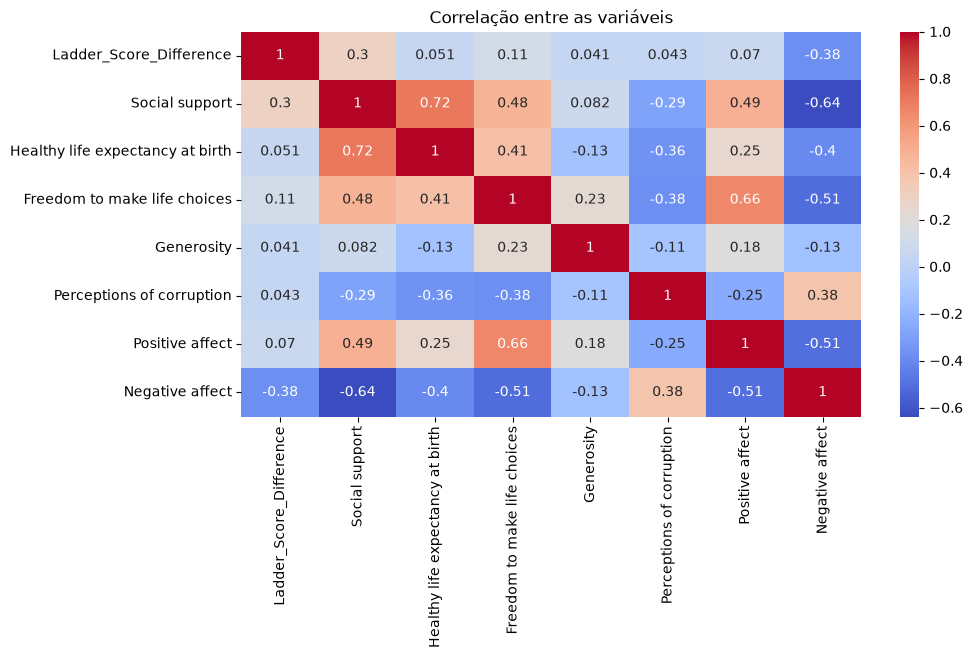

In [30]:
numerica_cols = df_merge_comparacao.select_dtypes(include = np.number).columns

correlation_matrix = df_merge_comparacao[numerica_cols].corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre as variáveis')
plt.show()

. A positive correlation of 0.3 between "Social support" and changes in happiness suggests that social support (having someone to rely on) may have played an important role in the countries that became happier during the pandemic, although this does not imply a direct causal relationship. This reflects the importance of emotional support networks in well-being and human happiness.

● A negative correlation of -0.38 between "Negative affect" and changes in happiness indicates that there may be a relationship between a decrease in happiness and the experience of negative emotions in the period close to the research. As we know, the COVID-19 pandemic created difficult moments for many people, and this correlation suggests that such experiences may have affected the perception of happiness in some countries.

# Happiness Trend with Linear Regression

By calculating the linear regression for the happiness index over time, it was possible to estimate how happiness has evolved in different countries. The slope of the line generated by the linear regression represents the rate of change in the happiness index for each country over the years.

* **Positive coefficient:** Countries with positive coefficients indicate a growing happiness trend, meaning these countries have shown improvement over time.

* **Negative coefficient:** Countries with negative coefficients indicate a declining trend, meaning these countries have become progressively less happy.

Below are the **10 countries with the greatest upward trend in happiness**, meaning those that have experienced the most significant increase in happiness over time (positive coefficients):

1. Serbia: coefficient 2.13
2. Bulgaria: coefficient 1.96
3. Guinea: coefficient 1.72
4. Romania: coefficient 1.71
5. Latvia: coefficient 1.70
6. Togo: coefficient 1.60
7. Hungary: coefficient 1.58
8. Republic of the Congo (Brazzaville): coefficient 1.57
9. Côte d'Ivoire: coefficient 1.53
10. Kosovo: coefficient 1.49

These countries have shown a steady improvement in happiness, with happiness values increasing over the years.

On the other hand, the **10 countries with the greatest decline in happiness** (negative coefficients) are:

1. Afghanistan: coefficient -2.80
2. Syria: coefficient -2.46
3. Lebanon: coefficient -2.42
4. Venezuela: coefficient -2.10
5. Angola: coefficient -1.74
6. Jordan: coefficient -1.71
7. Malawi: coefficient -1.54
8. Lesotho: coefficient -1.49
9. Zambia: coefficient -1.39
10. Botswana: coefficient -1.28

These countries are experiencing a significant decline in happiness over time, with happiness values steadily falling.

**Important:**

It is worth noting that these coefficients **do not indicate the happiest or saddest countries in absolute terms, but rather the countries with the strongest upward or downward trends in the happiness index over time**. In other words, a high positive coefficient means happiness has increased more rapidly over the years, while a negative coefficient indicates that happiness has decreased more sharply.

In [31]:
def calcular_tendencia(grupo):
  """Calculates the happiness trend based on all available years"""
  """Linear Regression"""
  anos = grupo.index.values

  felicidade = grupo['Life Ladder'].values

  # Verifying whether there are enough data points for the trend calculation:
  if len(anos) < 2:  # At least 2 points are required to calculate the trend
    return np.nan

  # Normalizing the years:
  anos_normalizados = (anos - anos.min()) / (anos.max() - anos.min())

  coeficientes = np.polyfit(anos_normalizados, felicidade, 1)
  return coeficientes[0]

df_tendencia = df.groupby('Country name')[['Life Ladder']].apply(calcular_tendencia).reset_index(name='Trend')

df_tendencia

,Country name,Trend
0,Afghanistan,-2.805400
1,Albania,0.043809
2,Algeria,-0.368091
3,Angola,-1.741500
4,Argentina,-0.284353
...,...,...
159,Venezuela,-2.073507
160,Vietnam,0.523255
161,Yemen,-1.088086
162,Zambia,-1.385382


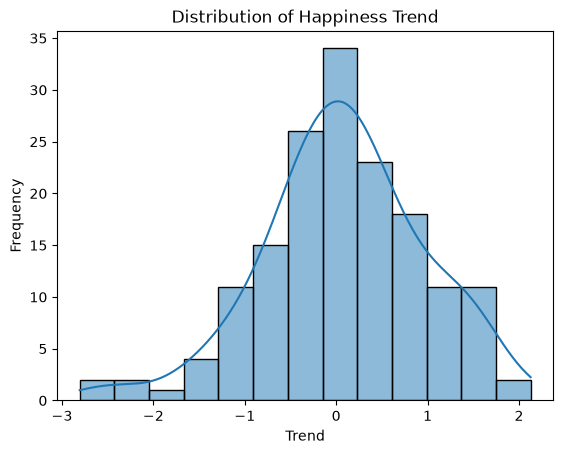

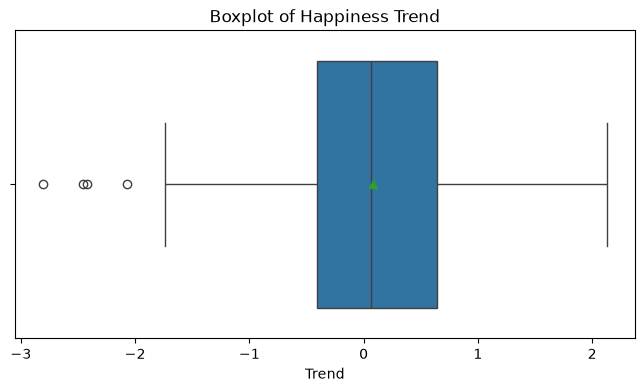

In [32]:
sns.histplot(df_tendencia['Trend'], kde=True)
plt.xlabel('Trend')
plt.ylabel('Frequency')
plt.title('Distribution of Happiness Trend')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_tendencia['Trend'], orient='h', showmeans=True)
plt.title('Boxplot of Happiness Trend')
plt.show()

Average trend per country: 0.07808916143292975
Median trend per country: 0.06136990950226069


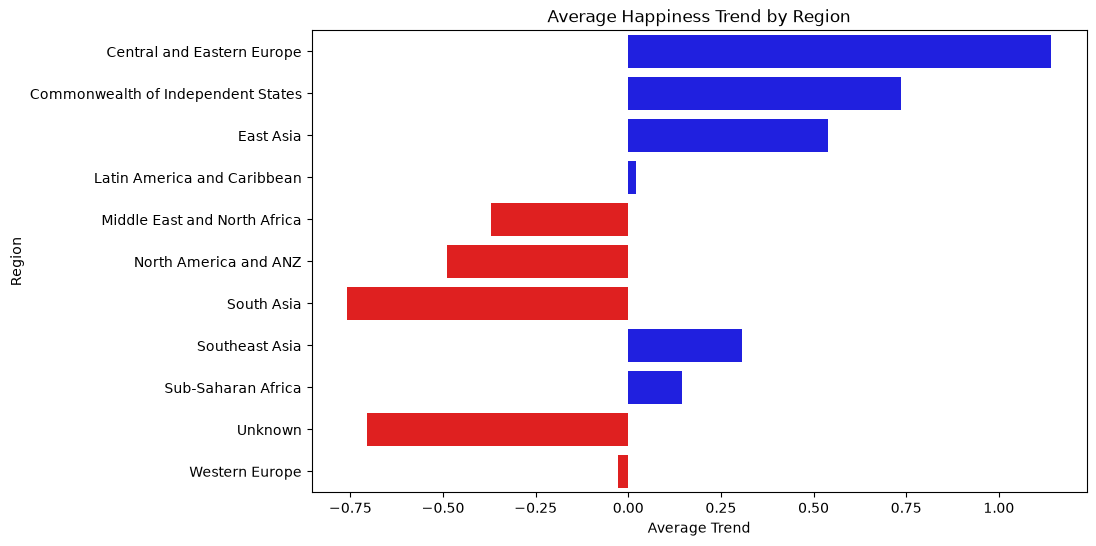

In [33]:
import plotly.express as px
import pandas as pd

# Mean and median happiness trend across countries
media_tendencia = df_tendencia['Trend'].mean()
print(f"Average trend per country: {media_tendencia}")
mediana_tendencia = df_tendencia['Trend'].median()
print(f"Median trend per country: {mediana_tendencia}")


# World map
max_abs_diff = max(abs(df_tendencia['Trend'].min()), abs(df_tendencia['Trend'].max()))
fig = px.choropleth(df_tendencia,
                    locations='Country name',
                    locationmode='country names',
                    color='Trend',
                    color_continuous_scale='RdBu',
                    range_color=[-max_abs_diff, max_abs_diff],
                    color_continuous_midpoint=0,
                    title='Happiness Trend')

# Adjust title position
fig.update_layout(
    title={
        'x': 0.5,
        'xanchor': 'center'
    },
    coloraxis_colorbar_tickvals=[df_tendencia['Trend'].min(), 0, df_tendencia['Trend'].max()],
)

fig.show()


# Showing average trends by region
df_tendencia_por_regiao = pd.merge(df_tendencia, df_regioes, on="Country name", how="left")
df_tendencia_por_regiao["Regional indicator"] = df_tendencia_por_regiao["Regional indicator"].fillna("Unknown")

unknown_countries = df_tendencia_por_regiao[df_tendencia_por_regiao['Regional indicator'] == 'Unknown']['Country name']

df_tendencia_por_regiao = df_tendencia_por_regiao.groupby('Regional indicator')['Trend'].mean().reset_index()

# Create the chart
plt.figure(figsize=(10, 6))

# Plot the chart
bars = sns.barplot(
    data=df_tendencia_por_regiao,
    x='Trend',
    y='Regional indicator',
    hue='Trend',
    dodge=False,
    palette={k: 'red' if k < 0 else 'blue' for k in df_tendencia_por_regiao['Trend']}
)

# Remove the legend generated by `hue`
bars.legend_.remove()

# Add labels and title
plt.xlabel('Average Trend')
plt.ylabel('Region')
plt.title('Average Happiness Trend by Region')
plt.show()

In [34]:
print(unknown_countries)

3                        Angola
11                      Belarus
13                       Belize
15                       Bhutan
22                      Burundi
26     Central African Republic
39                     Djibouti
57                       Guyana
58                        Haiti
90                     Maldives
111                        Oman
119                       Qatar
122                      Rwanda
130                     Somalia
131           Somaliland region
134                 South Sudan
138                       Sudan
139                    Suriname
142                       Syria
148         Trinidad and Tobago
150                Turkmenistan
151                     Türkiye
Name: Country name, dtype: str


In [35]:
top_10_happiness_trend_positive = df_tendencia.nlargest(10, 'Trend')

top_10_happiness_trend_positive

,Country name,Trend
125,Serbia,2.127000
20,Bulgaria,1.957800
56,Guinea,1.717187
120,Romania,1.711478
80,Latvia,1.699037
147,Togo,1.596091
61,Hungary,1.575243
32,Congo (Brazzaville),1.566286
70,Ivory Coast,1.529577
76,Kosovo,1.494353


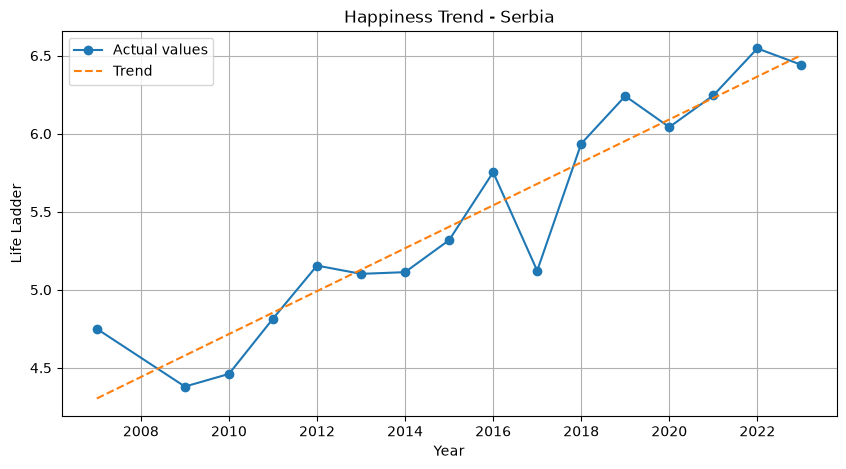

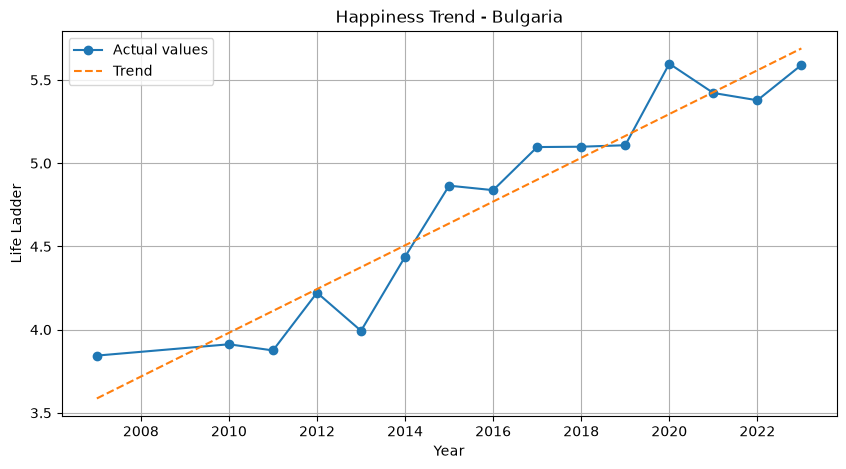

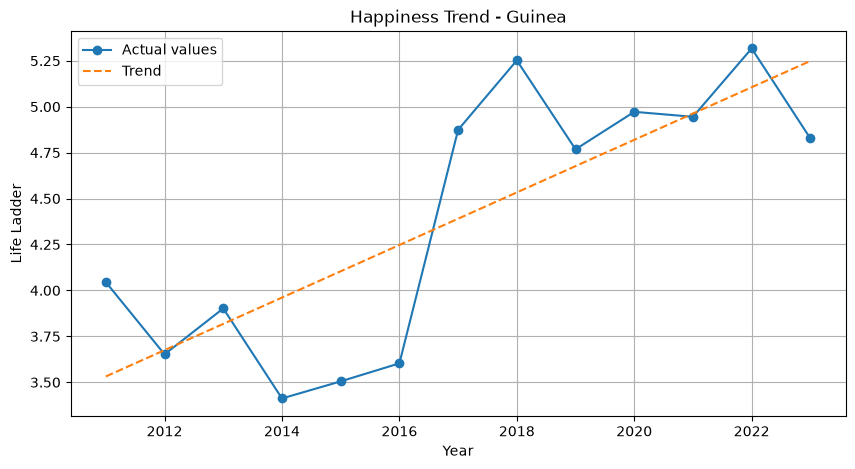

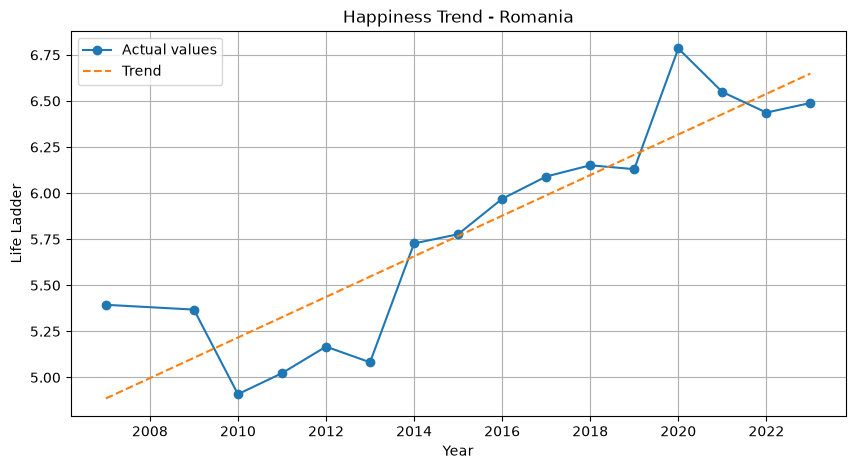

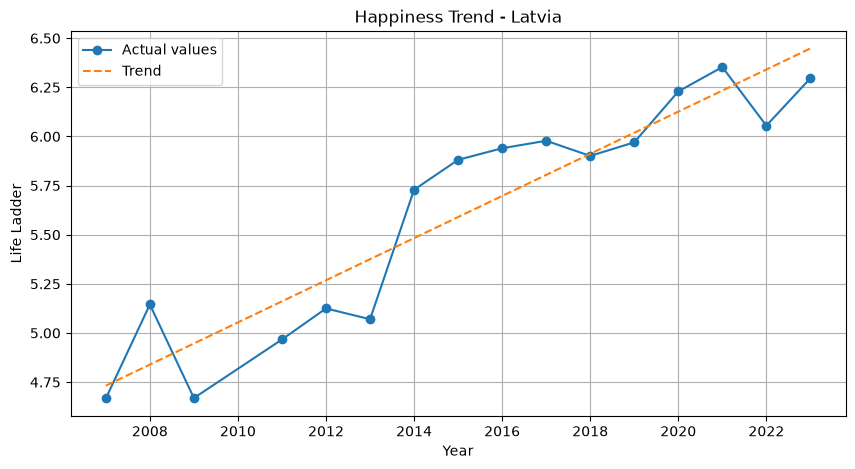

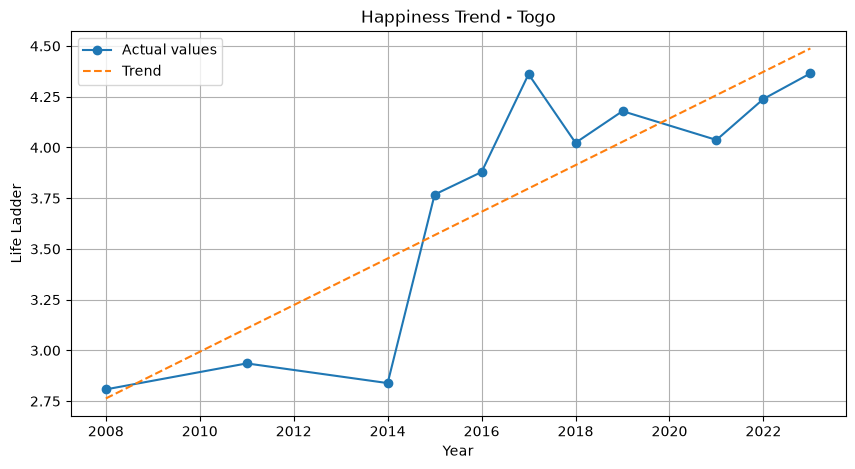

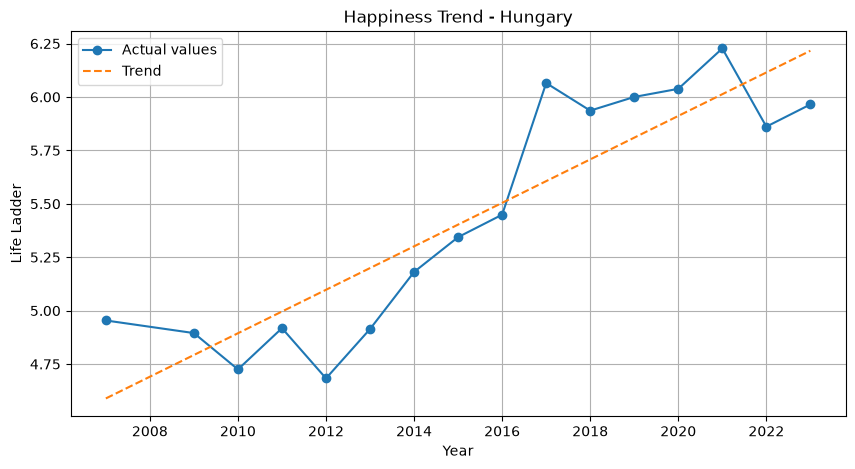

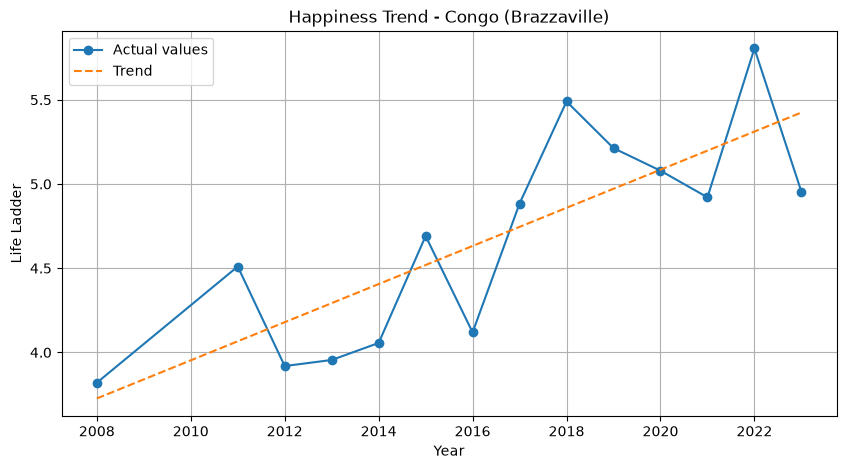

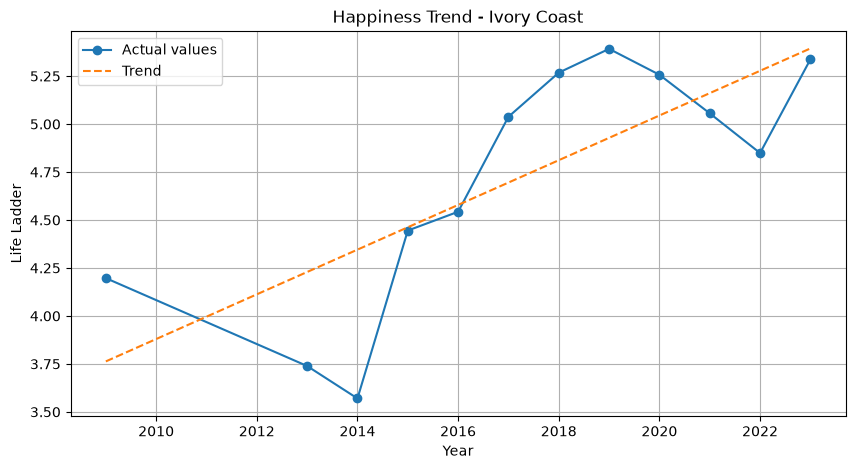

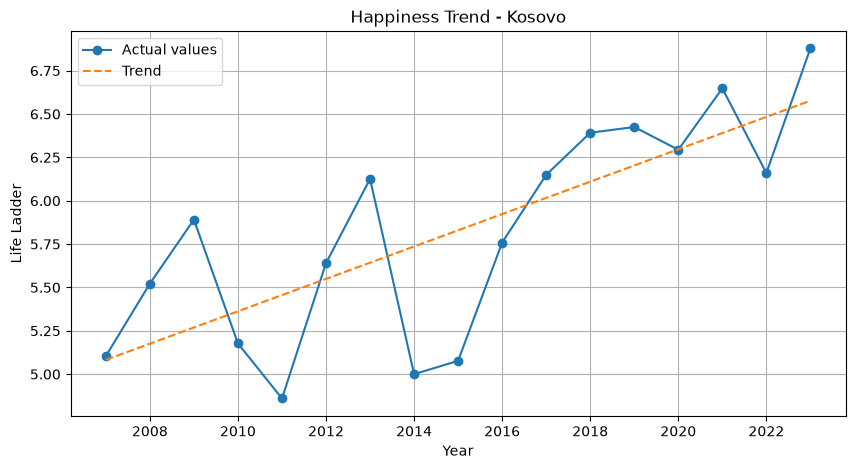

In [36]:
for pais in top_10_happiness_trend_positive['Country name']:
    # Filter the country's data
    dados_pais = df[df['Country name'] == pais]

    # Get years and Life Ladder values
    anos = dados_pais['year'].values
    felicidade = dados_pais['Life Ladder'].values

    # Calculate the trend line
    coeficientes = np.polyfit(anos, felicidade, 1)
    tendencia = np.polyval(coeficientes, anos)

    # Create the chart
    plt.figure(figsize=(10, 5))
    plt.plot(anos, felicidade, marker='o', label='Actual values')
    plt.plot(anos, tendencia, linestyle='--', label='Trend')

    plt.title(f'Happiness Trend - {pais}')
    plt.xlabel('Year')
    plt.ylabel('Life Ladder')
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
top_10_happiness_trend_negative = df_tendencia.nsmallest(10, 'Trend')

top_10_happiness_trend_negative


,Country name,Trend
0,Afghanistan,-2.805400
142,Syria,-2.457000
81,Lebanon,-2.418463
159,Venezuela,-2.073507
3,Angola,-1.741500
73,Jordan,-1.608039
88,Malawi,-1.535943
82,Lesotho,-1.488000
162,Zambia,-1.385382
18,Botswana,-1.279319


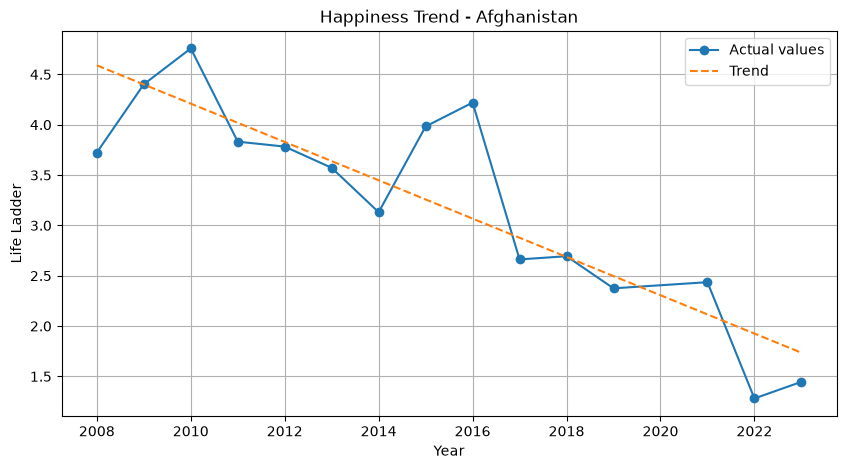

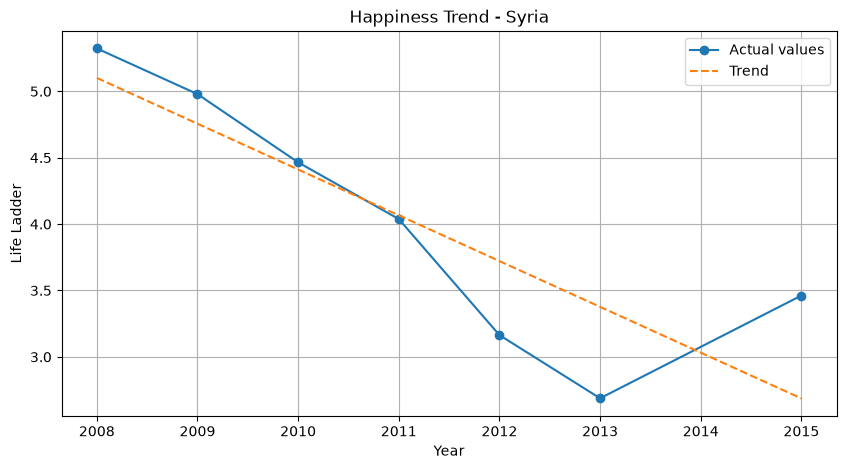

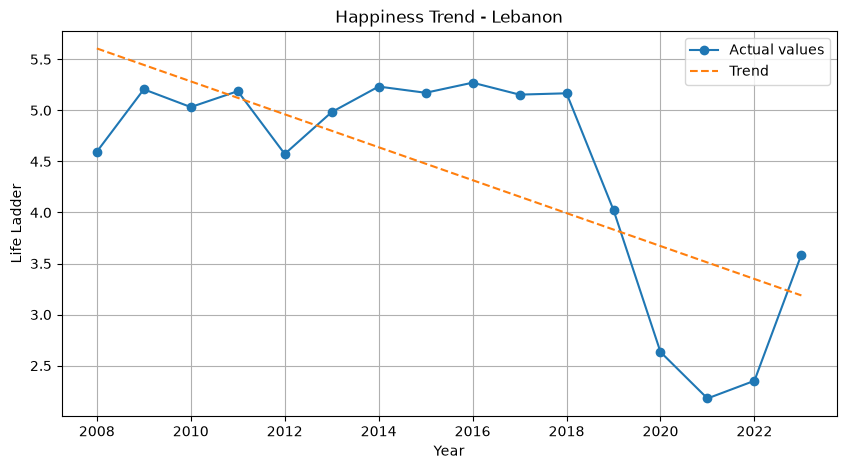

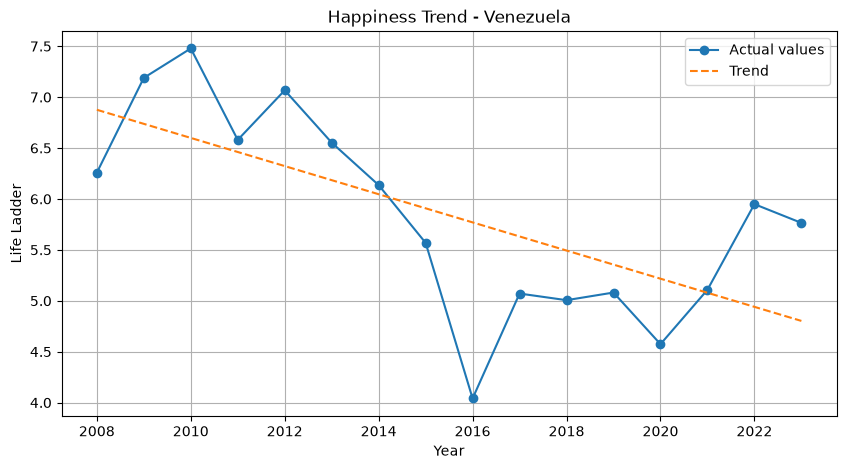

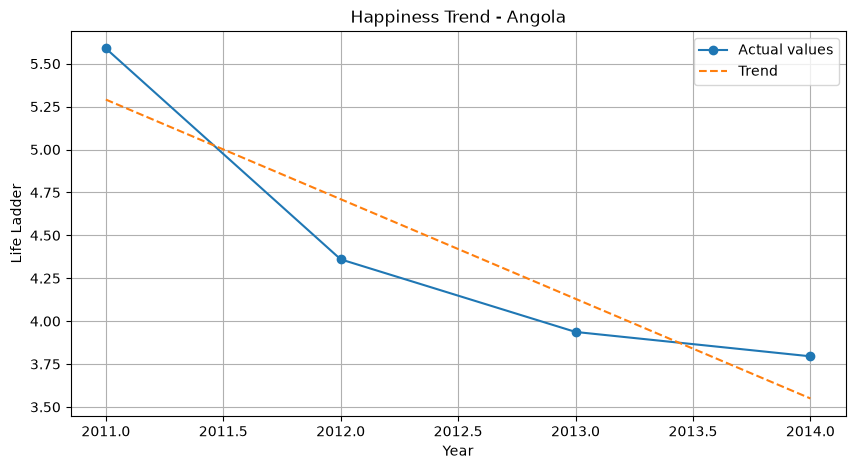

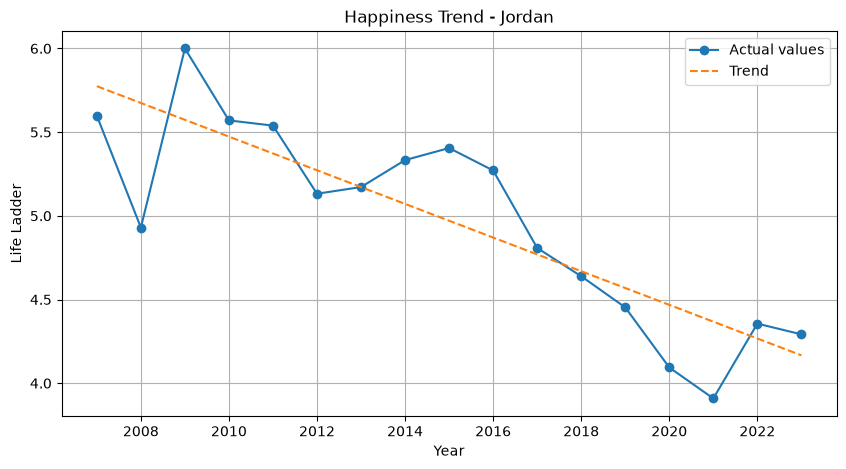

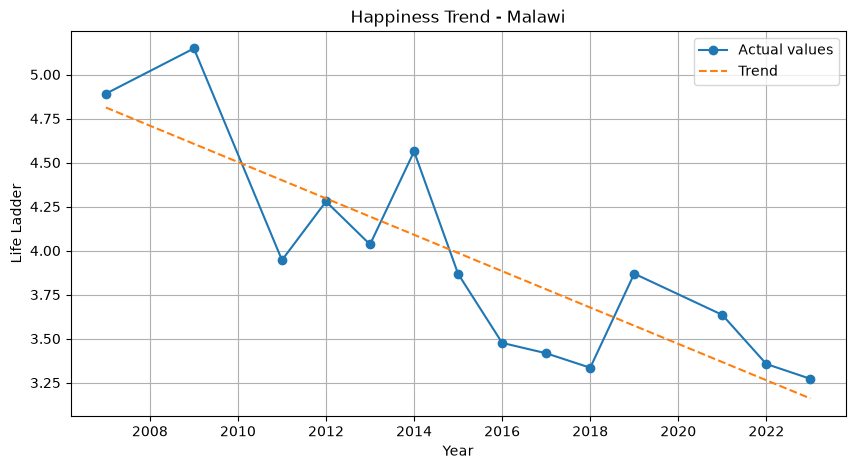

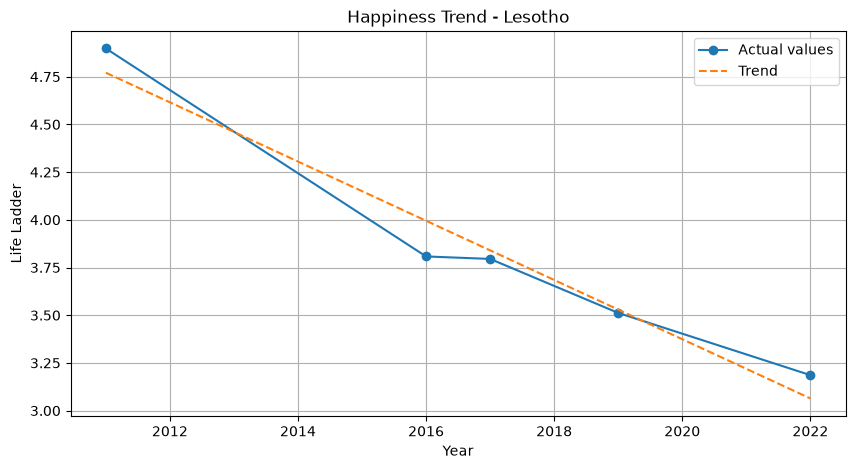

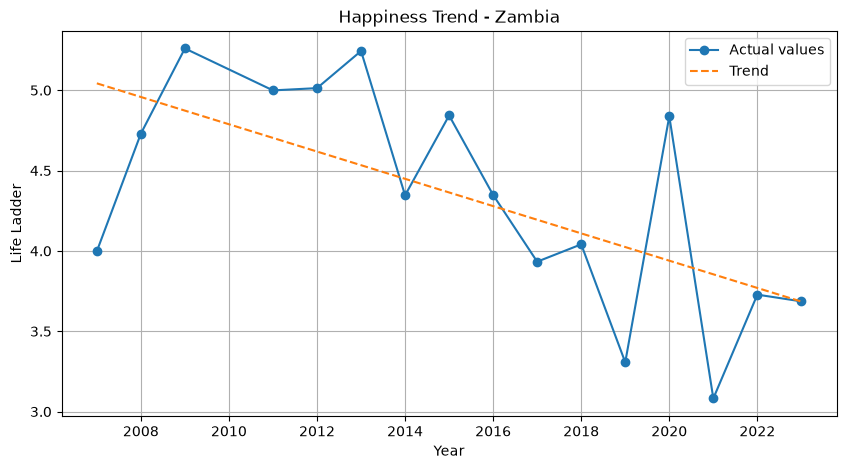

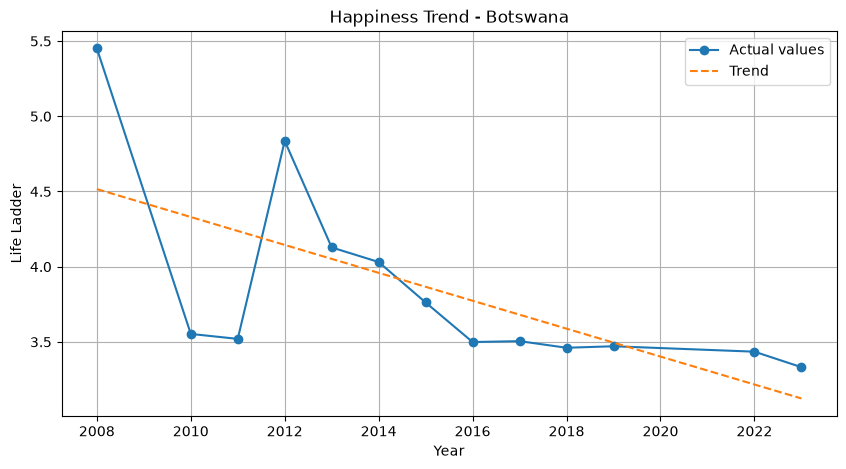

In [38]:
for pais in top_10_happiness_trend_negative['Country name']:
    # Filter the country's data
    dados_pais = df[df['Country name'] == pais]

    # Get years and Life Ladder values
    anos = dados_pais['year'].values
    felicidade = dados_pais['Life Ladder'].values

    # Calculate the trend line
    coeficientes = np.polyfit(anos, felicidade, 1)
    tendencia = np.polyval(coeficientes, anos)

    # Create the chart
    plt.figure(figsize=(10, 5))
    plt.plot(anos, felicidade, marker='o', label='Actual values')
    plt.plot(anos, tendencia, linestyle='--', label='Trend')

    plt.title(f'Happiness Trend - {pais}')
    plt.xlabel('Year')
    plt.ylabel('Life Ladder')
    plt.legend()
    plt.grid(True)
    plt.show()

# Applying machine learning models

We will apply 4 ML models, namely:

* Linear Regression
* Random Forest
* Decision Tree
* KNN

First, we will apply these models without including the 'Regional indicator' attribute in training.

In [39]:
# Criando um novo dataframe que incluirá as regiões no modelo de aprendizado de máquina
df_regioes = df

## Without including 'Regional indicator' in training

For this, we will train on the DataFrame 'df'

In [40]:
from sklearn.preprocessing import MinMaxScaler


# Applying normalization to numerical data
cols_para_normalizar = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
                       , 'Positive affect', 'Negative affect']

scaler = MinMaxScaler()

df[cols_para_normalizar] = scaler.fit_transform(df[cols_para_normalizar])

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df.drop(['Country name', 'year', 'Life Ladder', 'Regional indicator'], axis=1)
y = df['Life Ladder']

# Data split used only for attribute analysis in Random Forest
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# NOTE: The train/test split for model training will be performed using K-Fold

### Using Linear Regression

In [42]:
#### USING LINEAR REGRESSION WITH K-FOLD
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Setting up the model
lr_regressor = LinearRegression()

# Setting up K-Fold
k = 10  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring='r2')

# MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mae_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=mae_scorer)

# RMSE
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
rmse_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=rmse_scorer)

# Displaying results
print(f'Mean R²: {r2_scores.mean():.5f}')

print(f'Mean MAE: {-mae_scores.mean():.5f}')

print(f'Mean RMSE: {-rmse_scores.mean():.5f}')


Mean R²: 0.76509
Mean MAE: 0.41326
Mean RMSE: 0.54191


### Using Random Forest

In [45]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Configuring the RandomForest model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Defining the number of folds
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Lists to store the results
r2_scores = []
mae_scores = []
rmse_scores = []

# List to store predictions for all folds
y_pred_all = np.zeros_like(y)

# Performing K-Fold
for train_index, test_index in kf.split(X):
    # Splitting the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Training the model
    rf_regressor.fit(X_train, y_train)

    # Making predictions
    y_pred = rf_regressor.predict(X_test)

    # Storing predictions in the final array
    y_pred_all[test_index] = y_pred

    # Calculating metrics for each fold
    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Displaying results
print("Mean R²:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean RMSE:", np.mean(rmse_scores))

Mean R²: 0.8700742199602317
Mean MAE: 0.30172649807539675
Mean RMSE: 0.4022196861050917


There are several techniques to determine the importance of each feature in model prediction:
- Feature Importance
- SHAP

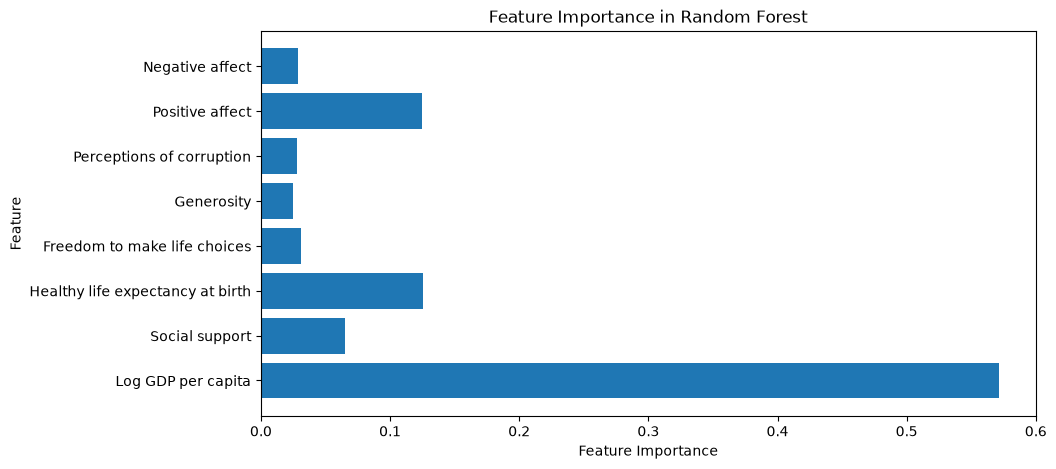

In [46]:
# Getting feature importance
importances = rf_regressor.feature_importances_

# Getting feature names
feature_names = X.columns

# Creating a bar chart
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Random Forest")
plt.show()

In [47]:
# Creating a SHAP explainer object for the Random Forest model
explainer = shap.TreeExplainer(rf_regressor, data=None, model_output='raw', feature_perturbation='tree_path_dependent')
# Calculating SHAP values for the test data
shap_values = explainer.shap_values(X_test)

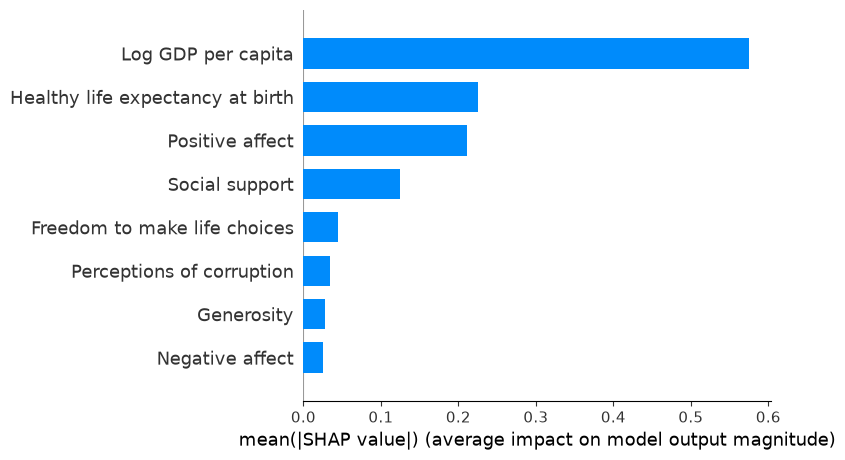

In [49]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

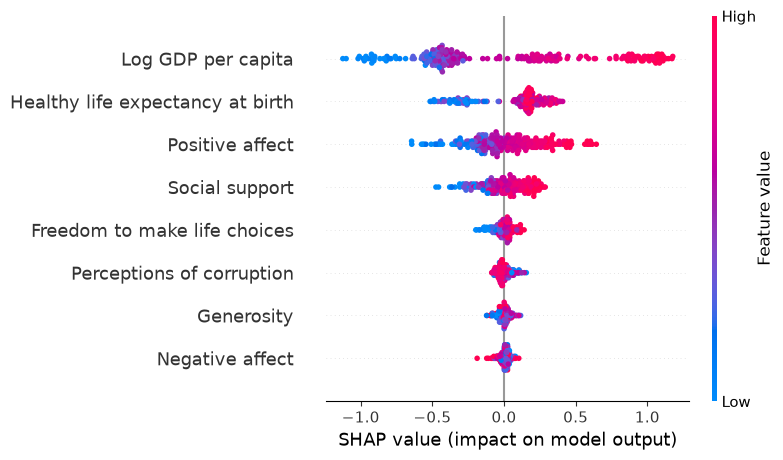

In [50]:
shap.summary_plot(shap_values,X_test)


### Using KNN

In [51]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Defining the KNN regressor model
knn_regressor = KNeighborsRegressor(n_neighbors=4)

# Setting up K-Fold
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Model evaluation with K-Fold cross-validation
r2_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_root_mean_squared_error')

# Predictions for all data using K-Fold
y_pred = cross_val_predict(knn_regressor, X, y, cv=kf)

# Displaying the evaluation metrics
print(f"Mean R²: {r2_scores.mean():.5f}")
print(f"Mean MAE: {-mae_scores.mean():.5f}")
print(f"Mean RMSE: {-rmse_scores.mean():.5f}")

Mean R²: 0.85937
Mean MAE: 0.30790
Mean RMSE: 0.41785


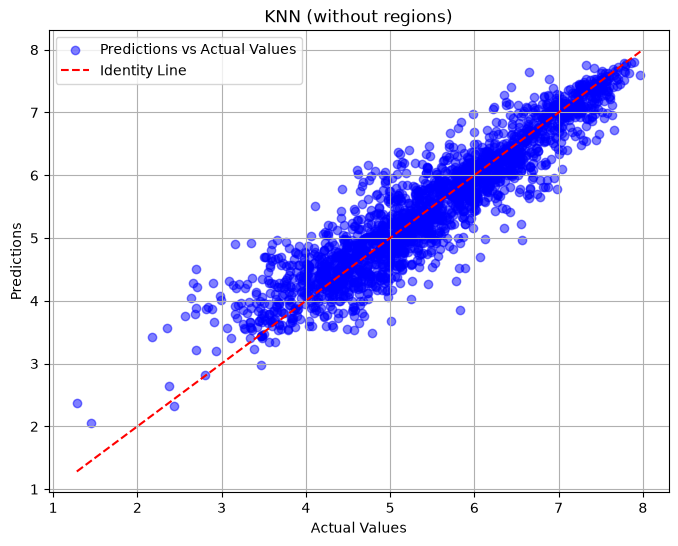

In [52]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Predictions vs Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Identity Line')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('KNN (without regions)')
plt.legend()
plt.grid(True)
plt.show()

## Including 'Regional indicator' in model training

We will repeat the four ML algorithms, this time including the region in model training through the dataframe `df_regioes`

In [53]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


# Splitting 'Regional indicator' into multiple binary attributes
encoder = OneHotEncoder(sparse_output=False, drop='first')
regioes_encoded = encoder.fit_transform(df_regioes[['Regional indicator']])

# Creating a DataFrame with the new values
regioes_encoded_df = pd.DataFrame(regioes_encoded, columns=encoder.get_feature_names_out(['Regional indicator']))
regioes_encoded_df.index = df_regioes.index

df_regioes = pd.concat([df_regioes, regioes_encoded_df], axis=1)

In [54]:
from sklearn.preprocessing import MinMaxScaler

# Applying normalization to the numerical data
cols_para_normalizar = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
                       'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
                       , 'Positive affect', 'Negative affect']

scaler = MinMaxScaler()

df_regioes[cols_para_normalizar] = scaler.fit_transform(df_regioes[cols_para_normalizar])

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_regioes.drop(['Country name', 'year', 'Life Ladder', 'Regional indicator'], axis=1)
y = df_regioes['Life Ladder']


# NOTE: The train/test split for model training will be performed using K-Fold

### Linear Regression

In [56]:
#### USING LINEAR REGRESSION WITH K-FOLD
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Setting up the model
lr_regressor = LinearRegression()

# Setting up K-Fold
k = 10  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring='r2')

# MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mae_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=mae_scorer)

# RMSE
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
rmse_scores = cross_val_score(lr_regressor, X, y, cv=kf, scoring=rmse_scorer)

# Displaying results
print(f'Mean R²: {r2_scores.mean():.5f}')

print(f'Mean MAE: {-mae_scores.mean():.5f}')

print(f'Mean RMSE: {-rmse_scores.mean():.5f}')

Mean R²: 0.78642
Mean MAE: 0.39107
Mean RMSE: 0.51673


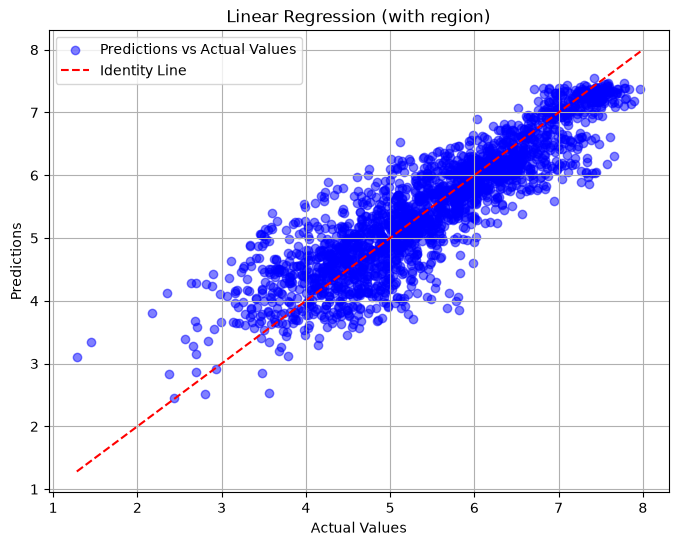

In [57]:
from sklearn.model_selection import cross_val_predict


# Predictions on the test set using cross-validation
y_pred = cross_val_predict(lr_regressor, X, y, cv=kf)

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Predictions vs Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Identity Line')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Linear Regression (with region)')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest

In [59]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Configuring the RandomForest model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Defining the number of folds
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Lists to store the results
r2_scores = []
mae_scores = []
rmse_scores = []

# List to store predictions for all folds
y_pred_all = np.zeros_like(y)

# Performing K-Fold
for train_index, test_index in kf.split(X):
    # Splitting the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Training the model
    rf_regressor.fit(X_train, y_train)

    # Making predictions
    y_pred = rf_regressor.predict(X_test)

    # Storing predictions in the final array
    y_pred_all[test_index] = y_pred

    # Calculating metrics for each fold
    r2_scores.append(r2_score(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Displaying results
print("Mean R²:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean RMSE:", np.mean(rmse_scores))

Mean R²: 0.8852252864044136
Mean MAE: 0.28281439315476187
Mean RMSE: 0.37766312021239845


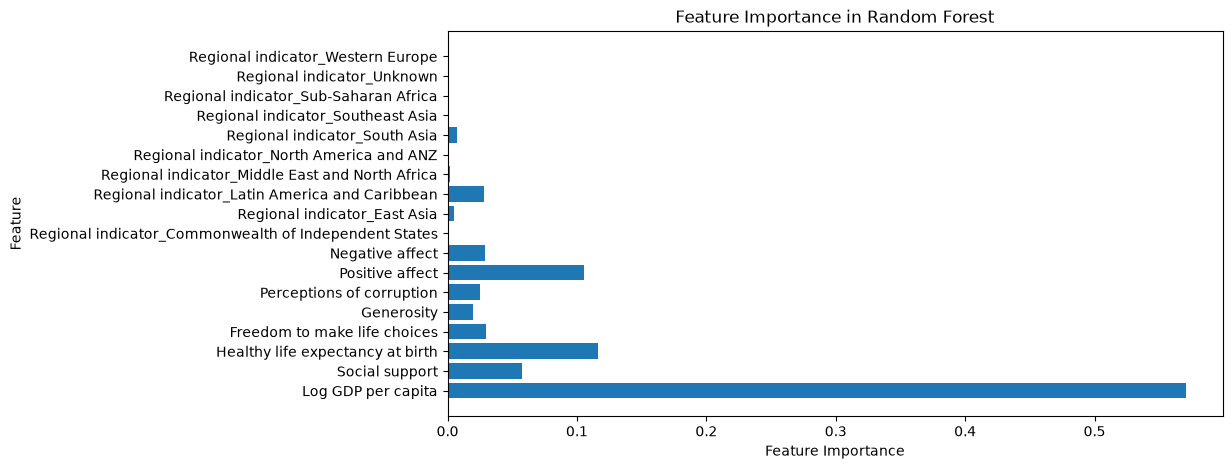

In [60]:
# Getting feature importance
importances = rf_regressor.feature_importances_

# Getting feature names
feature_names = X.columns

# Creating a bar chart
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Random Forest")
plt.show()

In [61]:
features = feature_names

for i in range(len(features)):
  print(features[i], ':', importances[i])


Log GDP per capita : 0.5703997903379676
Social support : 0.05786540592006226
Healthy life expectancy at birth : 0.11625065239088377
Freedom to make life choices : 0.03005334838455732
Generosity : 0.019360911233646597
Perceptions of corruption : 0.024789598082479138
Positive affect : 0.10519535318993074
Negative affect : 0.029048495537960673
Regional indicator_Commonwealth of Independent States : 0.0005713635055708526
Regional indicator_East Asia : 0.005351612781332451
Regional indicator_Latin America and Caribbean : 0.028148611524463414
Regional indicator_Middle East and North Africa : 0.0019341701743469607
Regional indicator_North America and ANZ : 0.0002909877215574145
Regional indicator_South Asia : 0.007642749239660551
Regional indicator_Southeast Asia : 0.0011215127519141504
Regional indicator_Sub-Saharan Africa : 0.0004437395511098051
Regional indicator_Unknown : 0.0009917414559777898
Regional indicator_Western Europe : 0.0005399562165785659


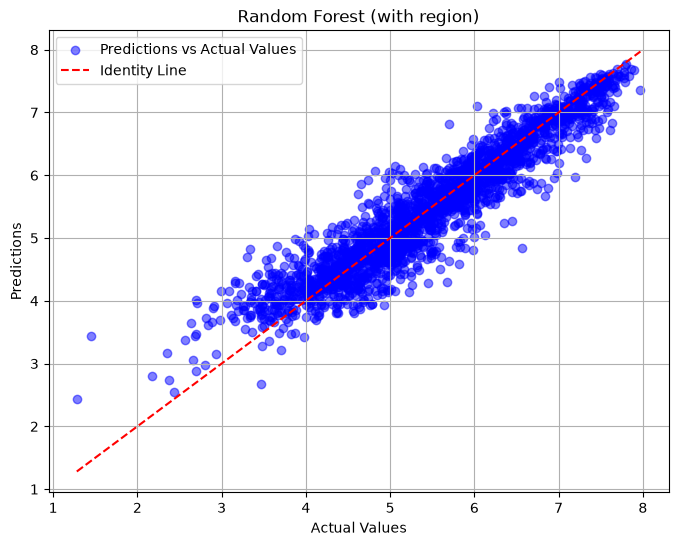

In [62]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, color='blue', alpha=0.5, label='Predictions vs Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Identity Line')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Random Forest (with region)')
plt.legend()
plt.grid(True)
plt.show()

### Decision Tree

In [63]:
from sklearn.tree import DecisionTreeRegressor


# Configuring the model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Setting up K-Fold
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Evaluating with K-Fold
r2_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring=make_scorer(mean_absolute_error, greater_is_better=False))
rmse_scores = cross_val_score(dt_regressor, X, y, cv=kf, scoring=make_scorer(root_mean_squared_error, greater_is_better=False))

# Making predictions for the full dataset and saving them
y_pred = cross_val_predict(dt_regressor, X, y, cv=kf)

# Displaying results
print(f"Mean R²: {r2_scores.mean():.5f}")
print(f"Mean MAE: {-mae_scores.mean():.5f}")
print(f"Mean RMSE: {-rmse_scores.mean():.5f}")

Mean R²: 0.77267
Mean MAE: 0.38871
Mean RMSE: 0.53211


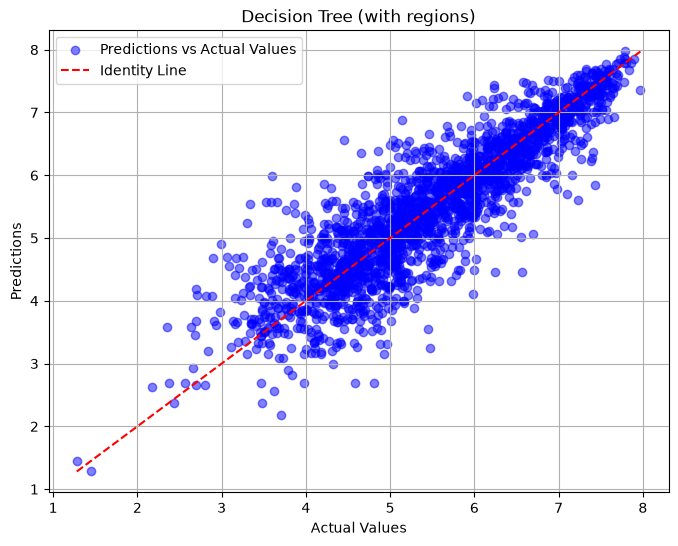

In [64]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Predictions vs Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Identity Line')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Decision Tree (with regions)')
plt.legend()
plt.grid(True)
plt.show()

### KNN

In [65]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Defining the KNN regressor model
knn_regressor = KNeighborsRegressor(n_neighbors=4)

# Setting up K-Fold
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Model evaluation with K-Fold cross-validation
r2_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_root_mean_squared_error')

# Predictions for all data using K-Fold
y_pred = cross_val_predict(knn_regressor, X, y, cv=kf)

# Displaying evaluation metrics
print(f"Mean R²: {r2_scores.mean():.5f}")
print(f"Mean MAE: {-mae_scores.mean():.5f}")
print(f"Mean RMSE: {-rmse_scores.mean():.5f}")

Mean R²: 0.87997
Mean MAE: 0.28414
Mean RMSE: 0.38610


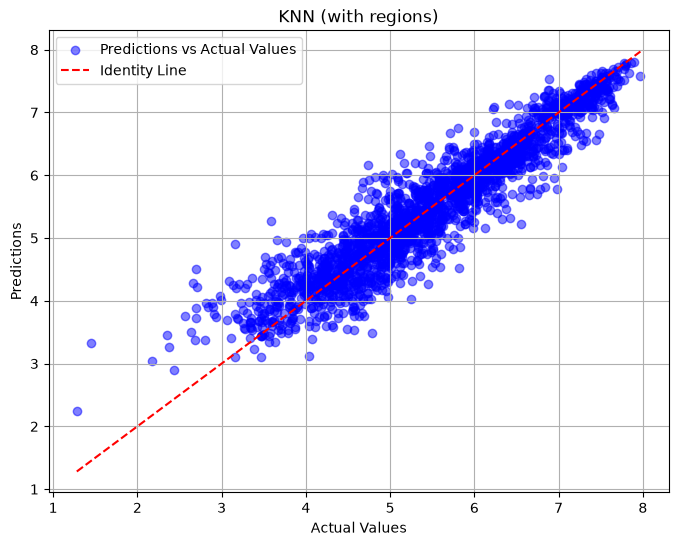

In [66]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Predictions vs Actual Values')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Identity Line')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('KNN (with regions)')
plt.legend()
plt.grid(True)
plt.show()